## Connect to Google Drive
It is convenient to load data from external source than manually drag it into colab env

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CatVTON for multiview try-on

## CatVTON and Libs installation

In [3]:
%cd /content
!git clone https://github.com/Zheng-Chong/CatVTON.git

/content
Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 29.33 MiB/s, done.
Resolving deltas: 100% (462/462), done.


In [4]:
%cd /content
# src/vton2d lives on the thesis_experiments branch; a plain clone takes main, which lacks it.
!rm -rf /content/CatVTON_3DGS
!git clone --depth 1 --branch thesis_experiments https://github.com/Eikthyrnir/CatVTON_3DGS.git


/content
Cloning into 'CatVTON_3DGS'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 4.13 MiB | 11.36 MiB/s, done.


In [5]:
%cd /content/CatVTON_3DGS
!pip uninstall -y torch torchvision torchaudio xformers torchao
!pip install -r requirements.txt

/content/CatVTON_3DGS
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 133.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 109.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 99.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# --- 2D evaluation support (vton2d) --------------------------------------
# Metrics, run persistence and the orbit driver live in the repo under src/vton2d, so they are
# version-controlled and can be re-run against saved artefacts in a later session. Everything is
# still driven from this notebook; nothing in the package imports torch, diffusers or CatVTON.
import os
import subprocess
import sys

REPO_DIR    = "/content/CatVTON_3DGS"
REPO_URL    = "https://github.com/Eikthyrnir/CatVTON_3DGS.git"
REPO_BRANCH = "thesis_experiments"      # main does NOT carry src/vton2d


def sh(*args):
    print("$", " ".join(args))
    out = subprocess.run(args, capture_output=True, text=True)
    if out.stdout.strip():
        print(out.stdout.strip())
    if out.returncode != 0 and out.stderr.strip():
        print(out.stderr.strip())
    return out.returncode


if not os.path.isdir(REPO_DIR):
    sh("git", "clone", "--depth", "1", "--branch", REPO_BRANCH, REPO_URL, REPO_DIR)
else:
    # An earlier cell may have cloned main, or cloned this branch before the latest push.
    sh("git", "-C", REPO_DIR, "fetch", "--depth", "1", "origin", REPO_BRANCH)
    sh("git", "-C", REPO_DIR, "checkout", "-B", REPO_BRANCH, "FETCH_HEAD")

if os.path.join(REPO_DIR, "src") not in sys.path:
    sys.path.append(os.path.join(REPO_DIR, "src"))

if not os.path.isdir(os.path.join(REPO_DIR, "src", "vton2d")):
    raise SystemExit(
        f"{REPO_DIR}/src/vton2d is missing.\n"
        f"It lives on the '{REPO_BRANCH}' branch, so check that branch is pushed:\n"
        f"    git push origin {REPO_BRANCH}\n"
        f"A plain 'git clone' takes 'main', which does not carry it."
    )

# Drop any cached copy, so re-running this cell after a push actually picks up the new code.
for _m in [m for m in list(sys.modules) if m == "vton2d" or m.startswith("vton2d.")]:
    del sys.modules[_m]

import vton2d
from vton2d import (RunConfig, RunWriter, run_orbit, ensure_orbit, score_run, report_run,
                    compare_runs, backfill_view_of, load_run, mask_iou,
                    list_runs, export_stage, count_decoder_attn1)
print("vton2d", vton2d.__version__, "from", vton2d.__file__)

# Optional, and only for the pairwise perceptual comparison of thesis Section 5.2.5. The CUDA
# version conflicts pip reports in Colab are pre-existing and unrelated to this package.
!pip install -q lpips


$ git -C /content/CatVTON_3DGS fetch --depth 1 origin thesis_experiments
$ git -C /content/CatVTON_3DGS checkout -B thesis_experiments FETCH_HEAD
Your branch is up to date with 'origin/thesis_experiments'.
vton2d 0.1.0 from /content/CatVTON_3DGS/src/vton2d/__init__.py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.8 MB/s eta 0:00:00


## CatVTON imports

In [2]:
%cd /content/CatVTON

/content/CatVTON


In [3]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download

import os
import gc

# imports from CatVTON
from model.cloth_masker import AutoMasker
from model.pipeline import CatVTONPipeline

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

## Initializing CatVTON models

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
from diffusers import AutoencoderKL
import torch

weight_dtype = torch.float16

base_model_path = "runwayml/stable-diffusion-inpainting"
catvton_model_path = "zhengchong/CatVTON"

pipeline = CatVTONPipeline(
    base_ckpt=base_model_path,
    attn_ckpt=catvton_model_path,
    attn_ckpt_version="mix",
    weight_dtype=weight_dtype,
    device=device,
    skip_safety_check=True
)

# Fix for the pink mask overlay and brown artifacts on T4:
# We use the official MSE-finetuned VAE which is safe in float16 and maintains high quality.
pipeline.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=weight_dtype).to(device)

# Built-in memory optimization
try:
    pipeline.enable_xformers_memory_efficient_attention()
    print("xformers optimization enabled.")
except Exception:
    print("Using built-in SDPA optimization.")

try:
    if hasattr(pipeline, "enable_model_cpu_offload"):
        pipeline.enable_model_cpu_offload()
        print("CPU offloading enabled!")
except Exception as e:
    print(f"Failed to enable CPU offloading: {e}")

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

dresscode-16k-512/attention/model.safete(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

vitonhd-16k-512/attention/model.safetens(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

mix-48k-1024/attention/model.safetensors:   0%|          | 0.00/198M [00:00<?, ?B/s]

flux-lora/pytorch_lora_weights.safetenso(…):   0%|          | 0.00/37.4M [00:00<?, ?B/s]

Downloaded zhengchong/CatVTON to /root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79
Using built-in SDPA optimization.


In [7]:
repo_path = snapshot_download(repo_id="zhengchong/CatVTON")

automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device=device
)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location='cpu')['state_dict']


## Utility functions

In [8]:
def show_try_on_res(person, mask, try_on_result):
    fig, axs = plt.subplots(1, 3, figsize=(15, 6))

    axs[0].imshow(person)
    axs[0].set_title("Front Result (Reference)")
    axs[0].axis('off')

    axs[1].imshow(mask)
    axs[1].set_title("Try-On Mask")
    axs[1].axis('off')

    axs[2].imshow(try_on_result.resize(target_size))
    axs[2].set_title("Try-On Result")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

In [9]:
def show_multiple_images(images):
    n_images = len(images)
    fig, axs = plt.subplots(1, n_images, figsize=(5 * n_images, 6))

    if n_images == 1:
        axs.imshow(images[0])
        axs.axis('off')
    else:
        for i in range(n_images):
            axs[i].imshow(images[i])
            axs[i].axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path

def remove_background_from_all_in_dir(target_dir: Path, automasker):
    for file_path in target_dir.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            img_pil = Image.open(file_path).convert("RGB")

            # Use automasker to get human parsing
            res = automasker(img_pil)

            # schp_atr contains class 0 for background, >0 for human/clothes/etc.
            schp_atr = np.array(res['schp_atr'])

            # Create a binary mask (255 for human, 0 for background)
            mask = (schp_atr > 0).astype(np.uint8) * 255

            # Optional: Smooth the mask slightly to avoid harsh jagged edges
            kernel = np.ones((3, 3), np.uint8)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

            # Convert img to cv2 format (RGB -> BGR for saving)
            img_cv2 = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

            # Apply mask (sets background to pure black)
            img_bg_removed = cv2.bitwise_and(img_cv2, img_cv2, mask=mask)

            # Overwrite the original image in the folder so 3DGS uses the masked version
            cv2.imwrite(str(file_path), img_bg_removed)

In [11]:
def determine_view_angle(densepose_img):
    """
    Determines if the person is facing front, back, or side based on DensePose segmentation.
    """
    densepose_array = np.array(densepose_img)

    front_torso_pixels = np.sum(densepose_array == 2)
    back_torso_pixels = np.sum(densepose_array == 1)

    total_torso = front_torso_pixels + back_torso_pixels

    if total_torso == 0:
        return "unknown"

    # Simple heuristic to determine the angle
    if front_torso_pixels > back_torso_pixels * 2:
        return "front"
    elif back_torso_pixels > front_torso_pixels * 2:
        return "back"
    else:
        return "side"

In [12]:
from tqdm import tqdm

def calc_body_views(person_folder, automasker):
    # Get all image files in person_folder excluding front_person_path
    all_files = [
        os.path.join(person_folder, f)
        for f in os.listdir(person_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    body_params = {}
    for file_path in tqdm(all_files):
        person_img = Image.open(file_path).convert("RGB")

        automasker_res = automasker(person_img)
        densepose_img = np.array(automasker_res['densepose'])

        body_params[file_path] = {'view_type': determine_view_angle(densepose_img)}
    return body_params

In [13]:
import os
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator


def show_3DGS_loss_curve(log_dir, lambda_dssim=0.2):
    """
    Plots the loss curve from a 1st log file in 3DGS output directory
    log_dir - Path to the 3DGS output directory
    lambda_dssim - The weight of D-SSIM in the total loss (default 0.2 in 3DGS)
    """

    # Find the TensorBoard events file
    event_files = glob.glob(os.path.join(log_dir, "events.out.tfevents*"))

    if not event_files:
        print(f"No TensorBoard event files found in {log_dir}.")
        return

    for event_file in event_files:
        print(f"Found event file: {event_file}")
        # Load the event accumulator
        ea = event_accumulator.EventAccumulator(event_file)
        ea.Reload()

        # Check available tags (metrics)
        tags = ea.Tags()['scalars']
        print(f"Available tags (metrics): {tags}")

        l1_tag = 'train_loss_patches/l1_loss'
        total_tag = 'train_loss_patches/total_loss'

        if l1_tag in tags and total_tag in tags:
            # Extract steps and loss values
            l1_events = ea.Scalars(l1_tag)
            total_events = ea.Scalars(total_tag)

            steps = [e.step for e in l1_events]
            l1_losses = np.array([e.value for e in l1_events])
            total_losses = np.array([e.value for e in total_events])

            # Calculate D-SSIM: Total = (1 - lambda) * L1 + lambda * D-SSIM
            # D-SSIM = (Total - (1 - lambda) * L1) / lambda
            d_ssim_losses = (total_losses - (1.0 - lambda_dssim) * l1_losses) / lambda_dssim

            # Smooth Total Loss
            smoothed_total_losses = [np.mean(total_losses[max(0, i-50):i+1]) for i in range(len(total_losses))]

            # Plot the loss curve
            plt.figure(figsize=(10, 6))
            plt.plot(steps, l1_losses, label="L1 Loss", color='g', alpha=0.8)
            plt.plot(steps, d_ssim_losses, label="D-SSIM", color='r', alpha=0.8)
            plt.plot(steps, smoothed_total_losses, label="Total Loss (Smoothed)", color='b', linewidth=2)

            plt.yscale('log') # Use logarithmic scale on the y-axis
            plt.xlabel("Iterations")
            plt.ylabel("Loss (Log Scale)")
            plt.title("3DGS Training Losses over Iterations")
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend()
            plt.show()
            break

        else:
            print("Could not find any loss metrics in the TensorBoard logs.")

### Detect True Front using YOLOv8n-pose + Depth Anything V2
Instead of pixel width (which is vulnerable to camera distance), we calculate the Z-depth of both shoulders. The image where `abs(left_shoulder_depth - right_shoulder_depth)` is closest to 0 represents the most perfectly aligned front view.

In [14]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 13.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [15]:
import cv2
import math
import numpy as np
from ultralytics import YOLO

# 1. Initialize YOLOv8 Pose Model (using nano for speed, can be changed to yolov8x-pose.pt for highest accuracy)
yolo_pose_predictor = YOLO('yolov8n-pose.pt')

# 2. Function to extract shoulder width and keypoints
def get_yolov8n_shoulder_width_and_kpts(img_pil):
    # Convert PIL RGB to OpenCV BGR
    img_bgr = np.array(img_pil)[:, :, ::-1]

    # Run YOLOv8 pose inference
    results = yolo_pose_predictor(img_bgr, verbose=False)

    if len(results) == 0 or results[0].keypoints is None or len(results[0].keypoints.data) == 0:
        return None, np.zeros((17, 3))

    # Get keypoints for the first detected person
    # YOLOv8 format: [num_persons, 17, 3] where 3 is (x, y, confidence)
    keypoints = results[0].keypoints.data[0].cpu().numpy()

    # COCO format: 5 is Left Shoulder, 6 is Right Shoulder
    l_shoulder = keypoints[5]
    r_shoulder = keypoints[6]

    # YOLOv8 confidence scores are normalized 0-1, so 0.3 is a reasonable threshold
    if l_shoulder[2] > 0.3 and r_shoulder[2] > 0.3:
        # 2D Euclidean distance (accounts for tilt/lean)
        width = math.hypot(l_shoulder[0] - r_shoulder[0], l_shoulder[1] - r_shoulder[1])
        return width, keypoints
    return None, keypoints


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [16]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

# Load Depth Anything V2 model
depth_image_processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")
depth_model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf").to(device)

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

In [17]:
def get_shoulder_depth_diff(img_pil, keypoints):
    # keypoints format: [17, 3] from Detectron2 (x, y, score)
    # 5 is Left Shoulder, 6 is Right Shoulder
    l_shoulder = keypoints[5]
    r_shoulder = keypoints[6]

    # Prepare image for depth model
    inputs = depth_image_processor(images=img_pil, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = depth_model(**inputs)
        predicted_depth = outputs.predicted_depth

    # Interpolate to original size
    prediction = torch.nn.functional.interpolate(
        predicted_depth.unsqueeze(1),
        size=img_pil.size[::-1],
        mode="bicubic",
        align_corners=False,
    )

    depth_map = prediction.squeeze().cpu().numpy()

    # Get depth at shoulder coordinates (y, x)
    # Note: image coordinates are (x, y), numpy array is [y, x]
    l_x, l_y = int(l_shoulder[0]), int(l_shoulder[1])
    r_x, r_y = int(r_shoulder[0]), int(r_shoulder[1])

    # Ensure coordinates are within bounds
    h, w = depth_map.shape
    l_x, l_y = np.clip(l_x, 0, w-1), np.clip(l_y, 0, h-1)
    r_x, r_y = np.clip(r_x, 0, w-1), np.clip(r_y, 0, h-1)

    l_depth = depth_map[l_y, l_x]
    r_depth = depth_map[r_y, r_x]

    return abs(l_depth - r_depth)

In [18]:
def calc_yolov8n_deepanything_shoulder_depth(body_params, view_type='front'):
    shoulder_depth_diffs = {}

    for file_path in body_params.keys():
        if body_params[file_path]['view_type'] == view_type:
            img_pil = Image.open(file_path).convert("RGB")
            width, kpts = get_yolov8n_shoulder_width_and_kpts(img_pil)

            if width is not None:
                # Add visibility & width checks to filter out false 'front' detections
                l_score = kpts[5][2]
                r_score = kpts[6][2]

                # Thresholds: reject if confidence is too low OR if width is suspiciously small
                # (e.g. less than 60% of the maximum shoulder width found previously)
                if l_score < 0.2 or r_score < 0.2 or width < (np.max(width) * 0.6):
                    continue

                diff = get_shoulder_depth_diff(img_pil, kpts)
                shoulder_depth_diffs[file_path] = diff

    return shoulder_depth_diffs

### Detect True Front using MediaPipe 3D Pose Landmarks
Instead of a 2D pose model + depth estimation model, MediaPipe provides a `z` coordinate directly out-of-the-box which estimates the landmark depth relative to the subject's center of mass. We can find the image where `abs(left_shoulder.z - right_shoulder.z)` is minimized.

In [19]:
!pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 159.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.5.3 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.3 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.5.3 which is incompatible.
tobler 0.13.0 requires tqdm>=4.67, but you have tqdm 4.66.4 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [20]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request
from PIL import Image
import sys

# Download the model asset if it doesn't exist
model_path = 'pose_landmarker_heavy.task'
if not os.path.exists(model_path):
    urllib.request.urlretrieve('https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task', model_path)

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Initialize MediaPipe Pose Landmarker
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5)
mp_detector = vision.PoseLandmarker.create_from_options(options)

def get_mediapipe_shoulder_info(img_pil):
    # Convert PIL to NumPy array (MediaPipe expects RGB, which PIL provides)
    img_np = np.array(img_pil)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_np)

    detection_result = mp_detector.detect(mp_image)

    if not detection_result.pose_landmarks:
        return None, None, None

    landmarks = detection_result.pose_landmarks[0]
    # MediaPipe Pose: 11 is Left Shoulder, 12 is Right Shoulder
    l_shoulder = landmarks[11]
    r_shoulder = landmarks[12]

    # Visibility check (0.0 to 1.0)
    if l_shoulder.visibility < 0.5 or r_shoulder.visibility < 0.5:
        return None, None, None

    # x, y are normalized [0.0, 1.0]. Multiply by dimensions for pixel coords
    h, w, _ = img_np.shape
    l_x, l_y = l_shoulder.x * w, l_shoulder.y * h
    r_x, r_y = r_shoulder.x * w, r_shoulder.y * h

    # 2D Width in pixels
    width = math.hypot(l_x - r_x, l_y - r_y)

    # Calculate depth difference using MediaPipe's intrinsic z coordinate
    # Z is roughly the depth in 'image scale' relative to the hips
    depth_diff = abs(l_shoulder.z - r_shoulder.z)

    coords = {
        'left': (l_x, l_y),
        'right': (r_x, r_y)
    }
    return width, depth_diff, coords


def calc_mediapipe_shoulder_depth(body_params, view_type='front'):
    shoulder_depth_diffs = {}

    # Initialize max_width on the fly
    max_width = 0.0

    for file_path in body_params.keys():
        # Use the initial mask filter to process only rough front candidates
        if body_params[file_path]['view_type'] == view_type:
            img_pil = Image.open(file_path).convert("RGB")
            width, depth_diff, coords = get_mediapipe_shoulder_info(img_pil)

            if width is not None:
                # Update max_width dynamically
                max_width = max(max_width, width)

                # Optional width filter to ignore obvious false positives
                if width < (max_width * 0.6):
                    continue

                shoulder_depth_diffs[file_path] = (depth_diff, coords, width)

    return shoulder_depth_diffs


## Download cloch files from drive

In [21]:
!mkdir /content/clothes

In [22]:
!gdown 1wicLOM4du-HSUVFEhEMcyMsotRM6NCBb -O /content/clothes/cloth_from_zoolando_website.tar
!tar -xf /content/clothes/cloth_from_zoolando_website.tar -C /content/clothes

Downloading...
From: https://drive.google.com/uc?id=1wicLOM4du-HSUVFEhEMcyMsotRM6NCBb
To: /content/clothes/cloth_from_zoolando_website.tar
100% 4.83M/4.83M [00:00<00:00, 162MB/s]


# Modifying the U-Net for Reference-Driven Editing (consistent side-view try-on generation)

## Defining custon Reference Attention Processor

In [23]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from diffusers.models.attention_processor import Attention, AttnProcessor2_0


class ReferenceAttentionProcessor:
    """Caches keys/values on a reference pass and injects them on a target pass (thesis 4.4).

    The layer set and the step window are NOT fixed here. `install_reference_attention` decides
    which layers carry a processor and with what window, so that the layer ablation (Section 5.6)
    and the injection-window sweep (E7) can vary them per run.
    """

    def __init__(self, name="", window=(5, 45)):
        self.name = name
        self.window = tuple(window)
        self.injection_steps = range(*self.window)
        self.is_reference_pass = True
        self.bank_k = []
        self.bank_v = []
        self.step_idx = 0

    def clear_bank(self):
        self.bank_k.clear()
        self.bank_v.clear()
        self.step_idx = 0

    def reset_read_index(self):
        self.step_idx = 0

    def __call__(self, attn: Attention, hidden_states, encoder_hidden_states=None,
                 attention_mask=None, **kwargs):
        batch_size, sequence_length, _ = hidden_states.shape

        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads
        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if self.is_reference_pass:
            self.bank_k.append(key.clone().detach().cpu())
            self.bank_v.append(value.clone().detach().cpu())
        else:
            if self.step_idx in self.injection_steps and self.step_idx < len(self.bank_k):
                ref_k = self.bank_k[self.step_idx].to(key.device)
                ref_v = self.bank_v[self.step_idx].to(value.device)
                if key.shape[0] != ref_k.shape[0]:
                    multiplier = key.shape[0] // ref_k.shape[0]
                    ref_k = ref_k.repeat(multiplier, 1, 1, 1)
                    ref_v = ref_v.repeat(multiplier, 1, 1, 1)
                key = torch.cat([ref_k, key], dim=2)
                value = torch.cat([ref_v, value], dim=2)
            self.step_idx += 1

        with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False,
                                            enable_mem_efficient=True):
            try:
                hidden_states = F.scaled_dot_product_attention(
                    query, key, value, dropout_p=0.0, is_causal=False)
            except RuntimeError:
                with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=True,
                                                    enable_mem_efficient=True):
                    hidden_states = F.scaled_dot_product_attention(
                        query, key, value, dropout_p=0.0, is_causal=False)

        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = attn.to_out[0](hidden_states)
        if len(attn.to_out) > 1:
            hidden_states = attn.to_out[1](hidden_states)
        return hidden_states


def _is_ours(proc):
    # Not isinstance(): re-running this cell rebinds the class, so instances made by a previous
    # execution are of a different class object with the same name.
    return type(proc).__name__ == "ReferenceAttentionProcessor"


def _capture_original_processors(unet):
    """Snapshot the stock processors so non-selected layers can be RESTORED, never rebuilt.

    This matters more than it looks. CatVTON has no text encoder and substitutes a pass-through
    processor for every cross-attention layer; rebuilding those from a diffusers default would
    silently switch cross-attention back on and change the backbone under us. Only `attn1` layers
    that already carry one of ours are rebuilt, and for those the stock behaviour is plain SDPA
    self-attention.
    """
    out = {}
    for name, proc in unet.attn_processors.items():
        if _is_ours(proc):
            assert "attn1" in name, f"unexpected reference processor on {name}"
            out[name] = AttnProcessor2_0()
        else:
            out[name] = proc
    return out


def install_reference_attention(pipeline, mode="decoder", window=(5, 45), verbose=True):
    """Install LF-MA on the layer set named by `mode`; every other layer keeps its stock processor.

      "decoder"  attn1 in up_blocks - the proposed pipeline (thesis 4.4.4)
      "all"      every attn1 layer - the unrestricted baseline
      "none"     no injection anywhere
    """
    global _ORIGINAL_ATTN_PROCESSORS
    if "_ORIGINAL_ATTN_PROCESSORS" not in globals() or _ORIGINAL_ATTN_PROCESSORS is None:
        _ORIGINAL_ATTN_PROCESSORS = _capture_original_processors(pipeline.unet)

    def selected(name):
        if mode == "none" or "attn1" not in name:
            return False
        if mode == "decoder":
            return "up_blocks" in name
        if mode == "all":
            return True
        raise ValueError(f"unknown injection mode {mode!r}")

    procs, n = {}, 0
    for name, stock in _ORIGINAL_ATTN_PROCESSORS.items():
        if selected(name):
            procs[name] = ReferenceAttentionProcessor(name=name, window=window)
            n += 1
        else:
            procs[name] = stock
    total = len(procs)
    # Count BEFORE the call: diffusers' set_attn_processor pops each entry out of the dict it is
    # given, so len(procs) afterwards is 0. The processors are installed correctly either way.
    pipeline.unet.set_attn_processor(procs)
    if verbose:
        print(f"LF-MA mode={mode!r} window={tuple(window)}: "
              f"{n} of {total} attention layers carry injection")
    return n


def configure_from(config):
    """run_orbit hook: apply a RunConfig's injection settings to the model, once per run."""
    install_reference_attention(pipeline, mode=config.injection, window=tuple(config.window))


# Install the released configuration so the model is in a defined state from here on.
install_reference_attention(pipeline, mode="decoder", window=(5, 45))


LF-MA mode='decoder' window=(5, 45): 9 of 32 attention layers carry injection


9

## Install camenduru 3DGS (3DGS version for colab)

In [24]:
%cd /content
!git clone --recursive https://github.com/camenduru/gaussian-splatting
!pip install -q plyfile ninja

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 603, done.
remote: Total 603 (delta 0), reused 0 (delta 0), pack-reused 603 (from 1)
Receiving objects: 100% (603/603), 2.09 MiB | 34.00 MiB/s, done.
Resolving deltas: 100% (346/346), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects: 100% (174/174), done.        
remote: Total 3293 (delta 171), reused 280 (delta 148), pack-reused 2971 (from 1)        
Receiving objects:

In [25]:
%cd /content/gaussian-splatting

/content/gaussian-splatting


In [26]:
import sys
!{sys.executable} -m pip install setuptools==69.0.3

In [27]:
!{sys.executable} -m pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization

  Preparing metadata (setup.py) ... done


In [28]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'

In [29]:
!sed -i '1i #include <float.h>' /content/gaussian-splatting/submodules/simple-knn/simple_knn.cu

%cd /content/gaussian-splatting
!pip install ./submodules/simple-knn

/content/gaussian-splatting
Processing ./submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=simple_knn-0.0.0-cp312-cp312-linux_x86_64.whl size=3069545 sha256=90920222975b86c9f3e51b75a3ffd6f4969401ce2165a688c2a39f0037435532
  Stored in directory: /root/.cache/pip/wheels/0a/f2/1b/255828ebad94ea248378281b7926639d83ce4f394f0052800d
Successfully built simple_knn


## Split video into images

In [30]:
!mkdir -p /content/gaussian-splatting/input/vadim
# !cp /content/drive/MyDrive/weavella/images/Photos_Manual_Selection/9/vadim.MOV /content/gaussian-splatting/input/vadim/
!gdown 1MPlCmym-gT7Gndj92rsbMxIJMJF-rQhX -O /content/gaussian-splatting/input/vadim/vadim.MOV

Downloading...
From: https://drive.google.com/uc?id=1MPlCmym-gT7Gndj92rsbMxIJMJF-rQhX
To: /content/gaussian-splatting/input/vadim/vadim.MOV
100% 11.1M/11.1M [00:00<00:00, 209MB/s]


In [31]:
!mkdir -p /content/gaussian-splatting/input/vadim/init_frames
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/init_frames/%04d.jpg

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## Init front/back cloth images

In [32]:
target_size = (768, 1024)

In [33]:
# different front-back
garment_folder = "/content/clothes/cloth_from_zalando_website/jack-and-jones-jorsnake-crew-neck-t-shirt-z-nadrukiem-antique-white-ja222o5zp-a11"
# pure flat-out t-shirt image
front_garment_path = garment_folder + "/c238569c66eb42578c5a787c54e43731.webp"
back_garment_path  = garment_folder + "/ceac3aa9af9b451d8aa29df6cf5db6dc.webp"

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)

In [34]:
garment_folder = "/content/clothes/cloth_from_zalando_website/pier-one-t-shirt-z-nadrukiem-blue-pi922o06a-k11"

front_garment_path = garment_folder + "/e19d02303035487b9d418bb94adf1ef5.webp" # flat-lay packshot
back_garment_path  = garment_folder + "/d7caa0e46d5e4a94822a1285da83c046.webp" # on person
side_garment_path  = front_garment_path # on person

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

In [35]:
# different front-back + side image
garment_folder = "/content/clothes/cloth_from_zalando_website/the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11"

# front_garment_path = garment_folder + "/e8cb036024b94af8aaeb5b8d38dfcb7c.webp" # pure flat-out t-shirt image
front_garment_path = garment_folder + "/e3c8055f31754cbbbeff96938543fdc1.webp" # on person
# back_garment_path  = garment_folder + "/95c143c6284549e99409498bf1b92679.webp" # pure flat-out t-shirt image
back_garment_path  = garment_folder + "/0c220ec6788a456194fa5184802d1743.webp" # on person
side_garment_path  = garment_folder + "/c172d2683ba54fe299fdbc6b5023658d.webp" # on person

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

In [36]:
# different front-back + side image
garment_folder = "/content/clothes/cloth_from_zalando_website/dickies-t-shirt-basic-black-di622o037-q11"

front_garment_path = garment_folder + "/front.webp" # on person
back_garment_path  = garment_folder + "/back.webp" # on person
side_garment_path  = garment_folder + "/side.png" # on person

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

In [37]:
# different front-back + side image
garment_folder = "/content/clothes/cloth_from_zalando_website/urban-classics-t-shirt-basic-black-ur622o03j-q11"

front_garment_path = garment_folder + "/front.webp" # on person
back_garment_path  = garment_folder + "/back.webp" # on person
side_garment_path  = garment_folder + "/size.png" # on person, profile (the file is named size.png)

front_garment_image = Image.open(front_garment_path).convert("RGB").resize(target_size)
back_garment_image  = Image.open(back_garment_path).convert("RGB").resize(target_size)
side_garment_image  = Image.open(side_garment_path).convert("RGB").resize(target_size)

## Select Reference Front/Back images

In [38]:
person_folder = "/content/gaussian-splatting/input/vadim/init_frames"
body_params = calc_body_views(person_folder, automasker)

  0%|          | 0/58 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 58/58 [01:04<00:00,  1.11s/it]


### Yolo + Depth Anything 2 results visualization

In [39]:
# Sort and display (closest to 0 is better)
sorted_shoulder_diffs = dict(sorted(calc_yolov8n_deepanything_shoulder_depth(body_params).items(), key=lambda item: item[1]))
print("\nShoulder depth differences (sorted):")
for name, d in sorted_shoulder_diffs.items():
    print(f"{name}: {d:.4f}")

print(f"\nTrue front image detected (Depth Method): {list(sorted_shoulder_diffs.keys())[0]} with depth difference {list(sorted_shoulder_diffs.values())[0]:.4f}")


Shoulder depth differences (sorted):
/content/gaussian-splatting/input/vadim/init_frames/0011.jpg: 0.0209
/content/gaussian-splatting/input/vadim/init_frames/0010.jpg: 0.1057
/content/gaussian-splatting/input/vadim/init_frames/0054.jpg: 0.1625
/content/gaussian-splatting/input/vadim/init_frames/0012.jpg: 0.2293
/content/gaussian-splatting/input/vadim/init_frames/0024.jpg: 0.2787
/content/gaussian-splatting/input/vadim/init_frames/0013.jpg: 0.4256
/content/gaussian-splatting/input/vadim/init_frames/0009.jpg: 0.4580
/content/gaussian-splatting/input/vadim/init_frames/0056.jpg: 0.5942
/content/gaussian-splatting/input/vadim/init_frames/0014.jpg: 0.6069
/content/gaussian-splatting/input/vadim/init_frames/0008.jpg: 0.6781
/content/gaussian-splatting/input/vadim/init_frames/0002.jpg: 0.7988
/content/gaussian-splatting/input/vadim/init_frames/0023.jpg: 0.8180
/content/gaussian-splatting/input/vadim/init_frames/0057.jpg: 0.8219
/content/gaussian-splatting/input/vadim/init_frames/0055.jpg: 0.8

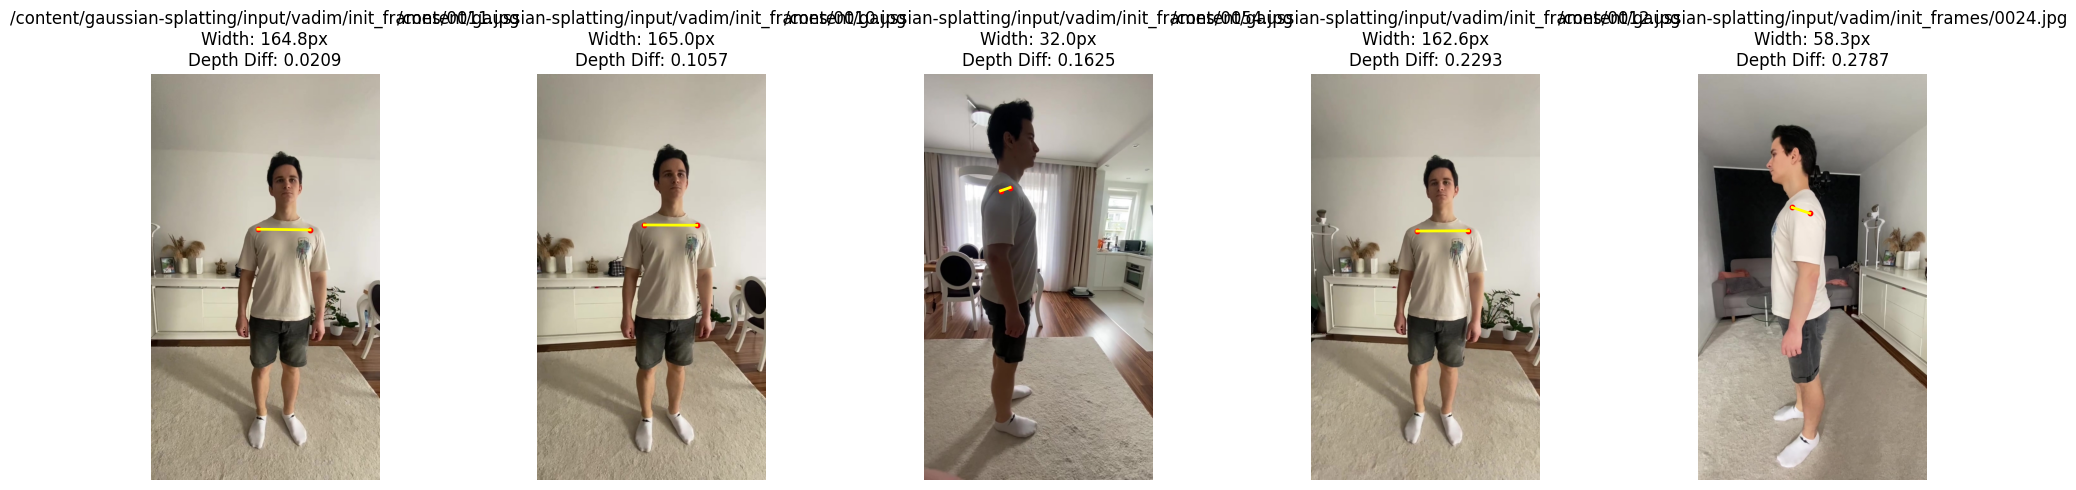

In [40]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Let's visualize the top 5 images with the lowest shoulder depth difference (best front views)
top_images = list(sorted_shoulder_diffs.keys())[:5]

fig, axes = plt.subplots(1, len(top_images), figsize=(20, 5))

for ax, img_name in zip(axes, top_images):
    img_path = os.path.join(person_folder, img_name)
    img_pil = Image.open(img_path).convert("RGB")

    # Get keypoints
    width, kpts = get_yolov8n_shoulder_width_and_kpts(img_pil)

    ax.imshow(img_pil)

    if width is not None:
        # 5: Left Shoulder, 6: Right Shoulder (x, y, conf)
        l_x, l_y = kpts[5][0], kpts[5][1]
        r_x, r_y = kpts[6][0], kpts[6][1]

        ax.scatter([l_x, r_x], [l_y, r_y], c='red', s=10, marker='o')
        ax.plot([l_x, r_x], [l_y, r_y], c='yellow', linestyle='-', linewidth=2)
        ax.set_title(f"{img_name}\nWidth: {width:.1f}px\nDepth Diff: {sorted_shoulder_diffs[img_name]:.4f}")
    else:
        ax.set_title(f"{img_name}\n(Not detected)")

    ax.axis('off')

plt.tight_layout()
plt.show()

### Mediapipe results visualization

In [41]:
# Sort and display (closest to 0 is better)
mp_sorted_shoulder_diffs = dict(sorted(calc_mediapipe_shoulder_depth(body_params).items(), key=lambda item: item[1][0]))

print(f"\nTrue front image detected (MediaPipe 3D Method): {list(mp_sorted_shoulder_diffs.keys())[0]} with Z-depth difference {list(mp_sorted_shoulder_diffs.values())[0][0]:.4f}")

print("\nMediaPipe Shoulder depth differences (sorted):")
for name, d in mp_sorted_shoulder_diffs.items():
    print(f"{name}: {d[0]:.4f}")


True front image detected (MediaPipe 3D Method): /content/gaussian-splatting/input/vadim/init_frames/0011.jpg with Z-depth difference 0.0099

MediaPipe Shoulder depth differences (sorted):
/content/gaussian-splatting/input/vadim/init_frames/0011.jpg: 0.0099
/content/gaussian-splatting/input/vadim/init_frames/0012.jpg: 0.0143
/content/gaussian-splatting/input/vadim/init_frames/0010.jpg: 0.0288
/content/gaussian-splatting/input/vadim/init_frames/0013.jpg: 0.0492
/content/gaussian-splatting/input/vadim/init_frames/0014.jpg: 0.0810
/content/gaussian-splatting/input/vadim/init_frames/0009.jpg: 0.1667
/content/gaussian-splatting/input/vadim/init_frames/0015.jpg: 0.1866
/content/gaussian-splatting/input/vadim/init_frames/0008.jpg: 0.2438
/content/gaussian-splatting/input/vadim/init_frames/0016.jpg: 0.2844
/content/gaussian-splatting/input/vadim/init_frames/0007.jpg: 0.4005
/content/gaussian-splatting/input/vadim/init_frames/0017.jpg: 0.4132
/content/gaussian-splatting/input/vadim/init_frames

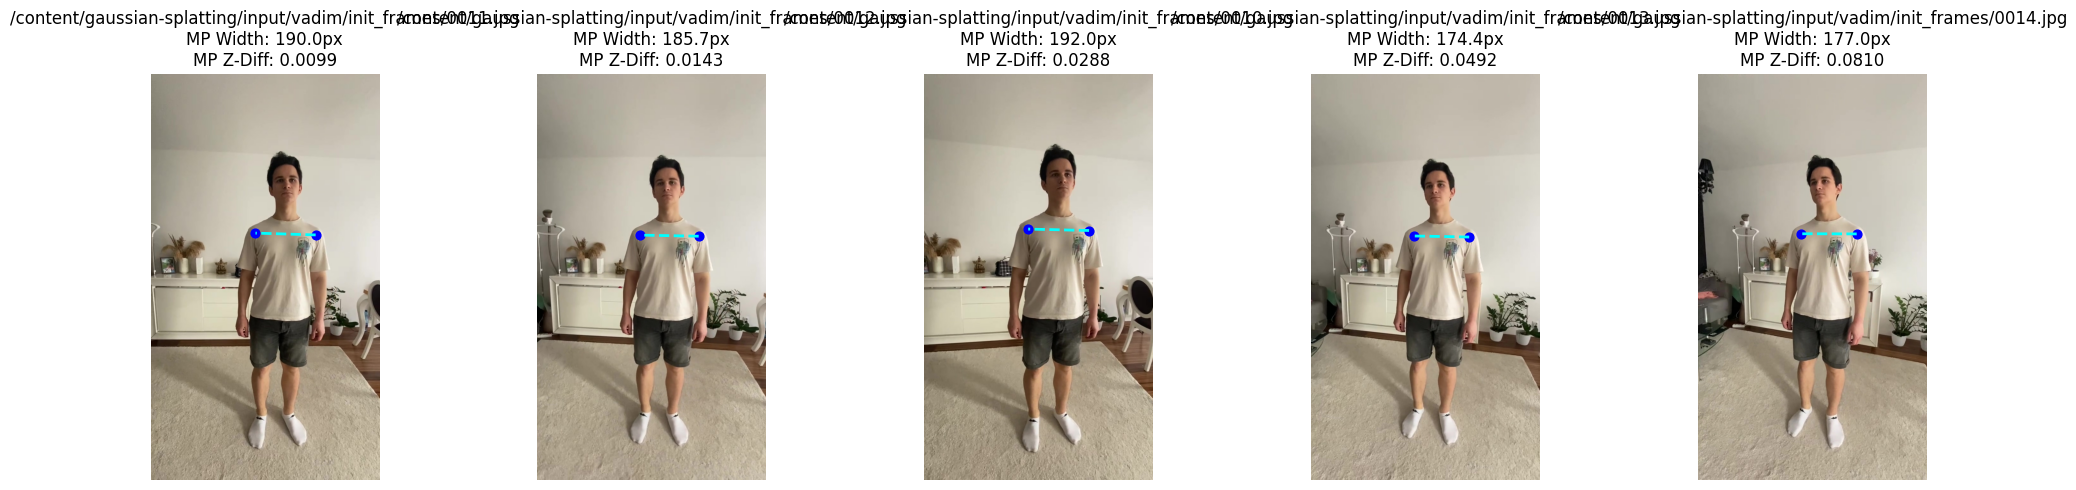

In [42]:
# Let's visualize the top 5 images with the lowest shoulder depth difference (MediaPipe)
mp_top_images = list(mp_sorted_shoulder_diffs.keys())[:5]

fig, axes = plt.subplots(1, len(mp_top_images), figsize=(20, 5))
if len(mp_top_images) == 1:
    axes = [axes]

for ax, img_name in zip(axes, mp_top_images):
    img_pil = Image.open(img_name).convert("RGB")

    depth_diff, coords, width = mp_sorted_shoulder_diffs.get(img_name)

    ax.imshow(img_pil)

    if coords is not None:
        l_x, l_y = coords['left']
        r_x, r_y = coords['right']

        # Use blue/cyan to distinguish from the YOLOv8 red/yellow visualization
        ax.scatter([l_x, r_x], [l_y, r_y], c='blue', s=40, marker='o')
        ax.plot([l_x, r_x], [l_y, r_y], c='cyan', linestyle='--', linewidth=2)
        ax.set_title(f"{img_name}\nMP Width: {width:.1f}px\nMP Z-Diff: {depth_diff:.4f}")
    else:
        ax.set_title(f"{img_name}\n(Not detected)")

    ax.axis('off')

plt.tight_layout()
plt.show()


### We will use mediapipe estimation as usually it gives more accurate results

In [43]:
def select_img_with_smallest_shoulder_depth_diff(body_params, view_type):
    depth_diff = calc_mediapipe_shoulder_depth(body_params, view_type)
    return sorted(depth_diff.items(), key=lambda item: item[1][0])[0][0]

In [44]:
person_folder = "/content/gaussian-splatting/input/vadim/init_frames"

front_person_path = select_img_with_smallest_shoulder_depth_diff(body_params, view_type='front')
back_person_path  = select_img_with_smallest_shoulder_depth_diff(body_params, view_type='back')

# Load and resize
front_person_img = Image.open(front_person_path).convert("RGB").resize(target_size)
back_person_img  = Image.open(back_person_path).convert("RGB").resize(target_size)

## Custom mask generators

In [45]:
def extract_upper_clothes_mask(mask_result):
    # Extract both SCHP lip and SCHP atr maps
    schp_lip = np.array(mask_result['schp_lip'])
    schp_atr = np.array(mask_result['schp_atr'])

    # Extract Upper-clothes from both models (LIP index 5, ATR index 4)
    lip_upper = (schp_lip == 5).astype(np.uint8) * 255
    atr_upper = (schp_atr == 4).astype(np.uint8) * 255

    # Evaluate which mask is "better" (heuristic: largest area)
    lip_area = np.sum(lip_upper > 0)
    atr_area = np.sum(atr_upper > 0)

    if lip_area > atr_area:
        print(f"  -> Selecting LIP upper-clothes mask (larger area: {lip_area} vs {atr_area})")
        return lip_upper
    else:
        print(f"  -> Selecting ATR upper-clothes mask (larger area: {atr_area} vs {lip_area})")
        return atr_upper


def schp_refine_mask(coarse_result, init_automasker_res, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement ---
    print("Phase 2: Refining Mask from Coarse Result...")
    # Run automasker on the coarse result to get exact boundaries of the new garment
    fine_mask_result = automasker(coarse_result)

    # Extract Upper-clothes mask
    upper_clothes_mask = extract_upper_clothes_mask(fine_mask_result)

    # --- Combine with Initial Coarse Mask ---
    initial_upper_clothes_mask = extract_upper_clothes_mask(init_automasker_res)
    upper_clothes_mask = cv2.bitwise_or(upper_clothes_mask, initial_upper_clothes_mask)

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise in the background)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes (like the ear-sized hole) using Contours
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays" or boundary holes
    # if close_ksize > 0:
    #     kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
    #     closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    # else:
    closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair) ---
    if init_automasker_res is not None:
        schp_atr = np.array(init_automasker_res['schp_atr'])
    else:
        schp_atr = np.array(fine_mask_result['schp_atr'])

    # ATR Labels: Hair=2, Belt=8, Bag=16, Scarf=17
    preserve_mask = np.isin(schp_atr, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")

    return refined_mask, [
        init_automasker_res['mask'].convert("L"),
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

In [46]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)

def segformer_refine_mask(coarse_result, init_automasker_res=None, dilate_size=1, dilate_iter=5, close_ksize=35):
    # --- Phase 2: Fine Mask Refinement (SegFormer) ---
    print("Phase 2: Refining Mask from Coarse Result using SegFormer...")

    # Run SegFormer on the coarse result image
    inputs = processor(images=coarse_result, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu()
    upsampled_logits = nn.functional.interpolate(
        logits,
        size=coarse_result.size[::-1], # (W, H) -> (H, W)
        mode="bilinear",
        align_corners=False,
    )
    pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()

    # Segformer B2 Clothes Upper-clothes class is 4
    upper_clothes_mask = (pred_seg == 4).astype(np.uint8) * 255

    # --- Combine with Initial Coarse Mask ---
    if init_automasker_res is not None:
        print("  -> Combining with initial coarse mask...")
        initial_upper_clothes_mask = extract_upper_clothes_mask(init_automasker_res)
        upper_clothes_mask = cv2.bitwise_or(upper_clothes_mask, initial_upper_clothes_mask)

    # --- Fix Holes and Small Artifacts ---
    # 1. Morphological Opening (removes small white artifacts/noise)
    kernel_small = np.ones((5, 5), np.uint8)
    cleaned_mask = cv2.morphologyEx(upper_clothes_mask, cv2.MORPH_OPEN, kernel_small)

    # 2. Fill internal holes using Contours (Less necessary for SegFormer, but good for safety)
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(cleaned_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

    # 3. Morphological Closing to fill concave "bays"
    if close_ksize > 0:
        kernel_close = np.ones((close_ksize, close_ksize), np.uint8)
        closed_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_CLOSE, kernel_close)
    else:
        closed_mask = filled_mask

    # --- Dilation for blending ---
    kernel = np.ones((dilate_size, dilate_size), np.uint8)
    refined_mask_np = cv2.dilate(closed_mask, kernel, iterations=dilate_iter)

    # --- Restore Intentional Holes (Bags, Belts, Hair, Scarves) ---
    if init_automasker_res is not None:
        schp_atr = np.array(init_automasker_res['schp_atr'])
        preserve_mask = np.isin(schp_atr, [2, 8, 16, 17]).astype(np.uint8) * 255
    else:
        # SegFormer Labels: Hair=2, Belt=8, Bag=16, Scarf=17
        preserve_mask = np.isin(pred_seg, [2, 8, 16, 17]).astype(np.uint8) * 255

    # Subtract the preserved accessories from the clothing mask
    refined_mask_np[preserve_mask == 255] = 0

    refined_mask = Image.fromarray(refined_mask_np).convert("L")

    return refined_mask, [
        Image.fromarray(upper_clothes_mask).convert("L"),
        Image.fromarray(cleaned_mask).convert("L"),
        Image.fromarray(filled_mask).convert("L"),
        Image.fromarray(closed_mask).convert("L"),
        Image.fromarray(refined_mask_np).convert("L")
    ]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

## Try-on: coarse -> composite -> refine (3 phases)

Phase 1  - Coarse try-on with CatVTON's WIDE garment-agnostic mask (the mask it was trained on):
           best garment fidelity, but the body (arms / neck) gets regenerated.

Phase 2  - Composite: build the tight cloth mask (union of the new + original upper-clothes, holes
           filled), carve out body + accessories, and PASTE Phase-1's garment onto the ORIGINAL
           person. Restores the exact original body, but the garment/skin seam can show a colour or
           shape discontinuity from blending two images.

Phase 3  - Refine: run a 2nd try-on ON THE COMPOSITE with the tight mask. Because the composite no longer contains the original shirt, the diffusion harmonizes the seam and refines the garment WITHOUT mixing in the old cloth (the failure mode of inpainting on the original).

final_mode:
-   "composite_refine" (default) - all 3 phases.
-   "composite" - phases 1-2 only (no refine pass; fastest, may show seams).
-   "inpaint" - legacy: phase 1 + a single tight-mask inpaint on the ORIGINAL person (washes out / mixes with the old garment).

In [47]:
def _set_reference_pass(pipeline, is_ref_pass):
    # Matched by class NAME, not isinstance: re-running the processor cell rebinds the class, and
    # an isinstance check would then quietly match nothing and disable LF-MA without any error.
    for proc in pipeline.unet.attn_processors.values():
        if type(proc).__name__ == "ReferenceAttentionProcessor":
            proc.is_reference_pass = is_ref_pass
            proc.clear_bank() if is_ref_pass else proc.reset_read_index()


def paste_back(person_img, tryon_img, garment_mask, feather=11):
    """Composite the garment region of `tryon_img` onto `person_img`, feathering the seam."""
    size = person_img.size
    p = np.array(person_img.convert("RGB")).astype(np.float32)
    t = np.array(tryon_img.convert("RGB").resize(size)).astype(np.float32)
    m = np.array(garment_mask.convert("L").resize(size)).astype(np.float32)
    if feather > 0:
        k = feather | 1                        # force odd kernel
        m = cv2.GaussianBlur(m, (k, k), 0)
    a = (m / 255.0)[..., None]                 # soft alpha in [0, 1]
    out = (t * a + p * (1.0 - a)).clip(0, 255).astype(np.uint8)
    return Image.fromarray(out)


def dilate_mask(mask, px):
    """Grow a binary mask by `px` pixels (ellipse kernel). Used to swallow the thin strip of the
    ORIGINAL garment that SCHP under-segments at the sleeve hem, so it is not left in the composite."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (px, px))
    dilated = cv2.dilate(np.array(mask.convert("L")), kernel, iterations=1)
    return Image.fromarray(dilated).convert("L")


def erode_mask(mask, px):
    """Shrink a binary mask by `px` pixels with an ISOTROPIC ellipse.

    NOT the operator of thesis eq:erosion. That one is *body-aware*: its ellipse takes its
    proportions from the DensePose torso bounding box and is elongated horizontally, so that it
    removes width padding while leaving the hem and shoulder lines alone. That implementation is
    not in this repository's history and its kernel size was never recorded, so it cannot be
    reproduced from what we have.

    Results from the "erosion" variant below must therefore NOT be reported as the published
    formulation. Either recover the original parameters, or label the variant an isotropic
    approximation wherever it appears.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (px, px))
    eroded = cv2.erode(np.array(mask.convert("L")), kernel, iterations=1)
    return Image.fromarray(eroded).convert("L")


def two_phase_tryon(person_img, garment_img, automasker, pipeline, mask_refiner_fun,
                    is_ref_pass=True, coarse_steps=50, fine_steps=50, seed=42, mask_dilate=14,
                    guidance_scale=2.5, mask_variant="composition"):
    """Two-Phase Mask Refinement with body-preserving composition (thesis Section 4.3).

    Returns a **dict** keyed by the artefact stages of `vton2d.runio.STAGES`, so that every
    intermediate reaches disk. The previous version returned a 4-tuple and the calling loops saved
    only the final image, which made both 2D metrics impossible to compute after the fact.

    `mask_variant` selects the construction under test (experiment E8):
      "composition"     released pipeline - refine, dilate, paste back, second pass on composite
      "no_composition"  refine, then second pass on the ORIGINAL frame with the refined mask.
                        Isolates the composition step alone, which is what Section 5.7 needs.
      "erosion"         as above but with the mask contracted first. An ISOTROPIC approximation
                        of eq:erosion, not the published body-aware operator - see erode_mask.
      "single_pass"     no refinement at all - the Phase-1 output with the cloth-agnostic mask

    The cloth-specific mask is computed in every variant, including "single_pass" where it is not
    used to generate anything. It defines the region the consistency measure is accumulated over
    (Section 5.2.3), so all three variants must be scored over the same kind of region for the
    comparison to mean anything.
    """
    # --- Phase 1: coarse try-on with the WIDE cloth-agnostic mask -------------
    print("Phase 1: Coarse mask + try-on...")
    coarse_mask_result = automasker(person_img)
    coarse_mask = coarse_mask_result["mask"]

    _set_reference_pass(pipeline, is_ref_pass)
    generator = torch.Generator(device=device).manual_seed(seed)
    coarse_result = pipeline(
        image=person_img, condition_image=garment_img, mask=coarse_mask,
        num_inference_steps=coarse_steps, guidance_scale=guidance_scale, generator=generator
    )[0]

    # --- Re-parse into a cloth-specific mask (Section 4.3.3) -----------------
    refined_mask, masks_inbetween = mask_refiner_fun(coarse_result, init_automasker_res=coarse_mask_result)

    artefacts = {
        "agnostic": coarse_mask,
        "densepose": coarse_mask_result.get("densepose"),
        "coarse": coarse_result,
        "cloth_mask": refined_mask,
        "comp_mask": None,
        "composite": None,
        "final": None,
        "parse_steps": list(masks_inbetween),
    }

    if mask_variant == "single_pass":
        # Ablation: no second pass at all. The delivered frame is the Phase-1 output.
        artefacts["final"] = coarse_result
        return artefacts

    if mask_variant == "no_composition":
        # Ablation: keep Two-Phase Mask Refinement, drop the composition. The second pass runs on
        # the ORIGINAL frame, where the previous garment is still present just outside the mask -
        # which is the contextual problem Section 4.3.6 introduced the composition to remove.
        second_mask = refined_mask
        second_input = person_img
    elif mask_variant == "erosion":
        # Isotropic approximation of the superseded contraction. See erode_mask before reporting.
        second_mask = erode_mask(refined_mask, mask_dilate)
        second_input = person_img
    elif mask_variant == "composition":
        second_mask = dilate_mask(refined_mask, mask_dilate)
        print("Phase 2: Paste-back composite...")
        second_input = paste_back(person_img, coarse_result, second_mask)
    else:
        raise ValueError(f"unknown mask_variant {mask_variant!r}")

    artefacts["comp_mask"] = second_mask
    artefacts["composite"] = second_input

    # --- Phase 3: refined pass (Section 4.3.5) -------------------------------
    print("Phase 3: Refine try-on...")
    _set_reference_pass(pipeline, is_ref_pass)
    generator = torch.Generator(device=device).manual_seed(seed)
    final_result = pipeline(
        image=second_input, condition_image=garment_img, mask=second_mask,
        num_inference_steps=fine_steps, guidance_scale=guidance_scale, generator=generator
    )[0]

    artefacts["final"] = final_result
    artefacts["parse_steps"] = list(masks_inbetween) + [second_mask, second_input, final_result]
    return artefacts

DensePose parts and their pixel counts for the front view:
Part 2: 48916 pixels
Part 3: 2379 pixels
Part 4: 2584 pixels
Part 5: 4062 pixels
Part 6: 4324 pixels
Part 9: 9403 pixels
Part 10: 8497 pixels
Part 13: 5675 pixels
Part 14: 5964 pixels
Part 15: 3790 pixels
Part 16: 3732 pixels
Part 17: 1700 pixels
Part 18: 1647 pixels
Part 19: 1926 pixels
Part 20: 1719 pixels
Part 21: 2745 pixels
Part 22: 2112 pixels
Part 23: 6898 pixels
Part 24: 6002 pixels


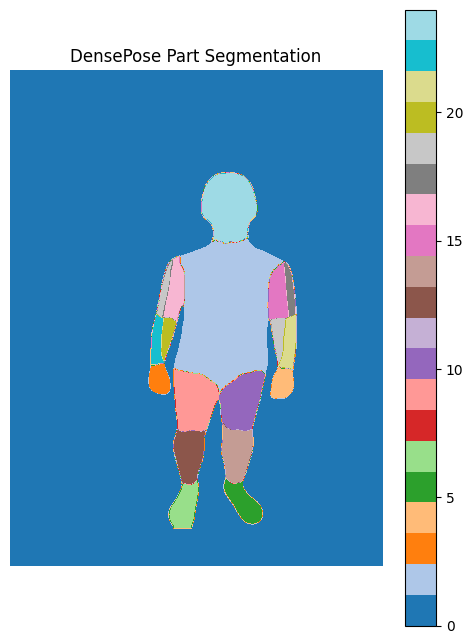

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# The mask_result from automasker contains 'densepose' along with 'mask'
# Let's run automasker on the front image to inspect it
automasker_res = automasker(front_person_img)
densepose_img = np.array(automasker_res['densepose'])

# Find unique part indices and their pixel counts
unique_parts, counts = np.unique(densepose_img, return_counts=True)
print("DensePose parts and their pixel counts for the front view:")
for part, count in zip(unique_parts, counts):
    # 0 is usually background
    if part != 0:
        print(f"Part {part}: {count} pixels")

# Visualize the DensePose map
plt.figure(figsize=(6, 8))
plt.imshow(densepose_img, cmap='tab20')
plt.title("DensePose Part Segmentation")
plt.colorbar()
plt.axis('off')
plt.show()

# By observing which part index has the most pixels in the torso area for front vs back views,
# we can create a simple heuristic to determine the angle!

## Front/Back/Side split Try-on per frame
This takes a lot of time! You can skip this and just download the results archive from Google Drive: [cell 'Download try-on results from Google Drive'](https://colab.research.google.com/github/Eikthyrnir/CatVTON_3DGS/blob/main/CatVTON_3DGS_pipeline.ipynb#scrollTo=GagRKKpNqbmO&line=1&uniqifier=1)

In [49]:
front_images = sorted([f for f in body_params.keys()
                       if os.path.abspath(f) != os.path.abspath(front_person_path)
                         and body_params[f]['view_type'] == 'front'
                       ],
                      key=os.path.basename)
back_images = sorted([f for f in body_params.keys()
                       if os.path.abspath(f) != os.path.abspath(back_person_path)
                         and body_params[f]['view_type'] == 'back'
                       ],
                      key=os.path.basename)
side_images = sorted([f for f in body_params.keys()
                       if body_params[f]['view_type'] == 'side'
                       ],
                      key=os.path.basename)

## 2D run: configuration

One `RunConfig` per configuration, one output directory per run, one manifest per directory. A
sweep overrides a single field with `cfg.variant_of(...)`. Never point two configurations at the
same directory: the second silently overwrites the first.

In [50]:
RUNS_ROOT = "/content/drive/MyDrive/weavella/runs_2d"   # on Drive so a run survives a restart
SUBJECT   = "vadim"
GARMENT   = "north-face-retro-earth-tee"

cfg = RunConfig(
    run_id=f"{SUBJECT}__{GARMENT}__released",
    subject=SUBJECT,
    garment=GARMENT,
    coarse_steps=50, fine_steps=50,          # T_1, T_2
    guidance_scale=2.5, ref_guidance_scale=5.0,
    mask_dilate=14, seed=42,
    resolution=target_size,
    mask_variant="composition",
    injection="decoder", window=(5, 45),
    notes="B1 reference corpus: the released configuration of tab:config",
)

frames_by_view = {"front": front_images, "back": back_images, "side": side_images}
# The north-face photographs, loaded here rather than taken from whichever garment's setup cell
# ran last: every scoring cell below reads them through garment_for, and running another garment's
# setup cell after the north-face one silently changes what those cells score against.
_NORTH_FACE = "/content/clothes/cloth_from_zalando_website/the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11"
garments = {view: Image.open(f"{_NORTH_FACE}/{name}").convert("RGB").resize(target_size)
            for view, name in (("front", "e3c8055f31754cbbbeff96938543fdc1.webp"),
                               ("back",  "0c220ec6788a456194fa5184802d1743.webp"),
                               ("side",  "c172d2683ba54fe299fdbc6b5023658d.webp"))}
references     = {"front": front_person_path, "back": back_person_path}

# frame stem -> orientation class, used when scoring to pick the conditioning photograph
view_of = {os.path.splitext(os.path.basename(p))[0]: v["view_type"] for p, v in body_params.items()}
garment_for = lambda name: garments[view_of.get(os.path.splitext(name)[0], "front")]

# Where this configuration's artefacts land. Defined here so every cell that reads the run
# back works after a runtime restart, without `writer` in scope.
RELEASED_RUN = f"{RUNS_ROOT}/{cfg.run_id}"

print({k: len(v) for k, v in frames_by_view.items()}, "| references:", list(references))
print("run dir:", RELEASED_RUN)

{'front': 28, 'back': 23, 'side': 5} | references: ['front', 'back']
run dir: /content/drive/MyDrive/weavella/runs_2d/vadim__north-face-retro-earth-tee__released


## 2D run: generate the orbit

`run_orbit` replaces the three near-duplicate loops. The generation order over the orientation
classes is **load-bearing** (thesis Section 4.4.2): a reference pass clears the key/value bank and
refills it, so lateral frames - each generated as its own reference pass, since they receive no
injection - must all run before the front reference fills the bank its targets consume.

`ensure_orbit` makes this cell safe to re-run from the top, which matters because a Colab runtime
can die part-way through an hour-long orbit:

* nothing on disk yet -> generates everything
* partially generated -> generates only what is missing, keeping what is there
* already complete -> generates nothing, just reports

The reference frame of a class is regenerated whenever any of its targets are, because its pass is
what fills the bank those targets read from and the bank does not survive a restart.

**`force=True` deletes the run and regenerates from scratch** - an hour of GPU on a full orbit.
It is the only path that destroys work, and it never happens by accident.


In [51]:
# The driver stays model-agnostic; the notebook supplies the callable.
tryon_fn = lambda person_img, garment_img, **kw: two_phase_tryon(
    person_img, garment_img, automasker, pipeline, schp_refine_mask, **kw)

summary = ensure_orbit(frames_by_view, garments, references, tryon_fn, cfg, RUNS_ROOT,
                       parse_steps_for=2, configure_fn=configure_from)
print(f"\ngenerated {summary['generated']}, reused {summary['reused']}")
summary

run already complete: 58 frame(s) in /content/drive/MyDrive/weavella/runs_2d/vadim__north-face-retro-earth-tee__released
nothing to generate. Pass force=True to regenerate from scratch (this DELETES the existing run).

generated 0, reused 58


{'run_dir': PosixPath('/content/drive/MyDrive/weavella/runs_2d/vadim__north-face-retro-earth-tee__released'),
 'frames': ['0001',
  '0002',
  '0003',
  '0004',
  '0005',
  '0006',
  '0007',
  '0008',
  '0009',
  '0010',
  '0011',
  '0012',
  '0013',
  '0014',
  '0015',
  '0016',
  '0017',
  '0018',
  '0019',
  '0020',
  '0021',
  '0022',
  '0023',
  '0024',
  '0025',
  '0026',
  '0027',
  '0028',
  '0029',
  '0030',
  '0031',
  '0032',
  '0033',
  '0034',
  '0035',
  '0036',
  '0037',
  '0038',
  '0039',
  '0040',
  '0041',
  '0042',
  '0043',
  '0044',
  '0045',
  '0046',
  '0047',
  '0048',
  '0049',
  '0050',
  '0051',
  '0052',
  '0053',
  '0054',
  '0055',
  '0056',
  '0057',
  '0058'],
 'generated': 0,
 'reused': 58}

## 2D run: export the final frames

The run directory is the archive. Downstream tools get a flat copy, so several configurations can
coexist without overwriting each other.

In [52]:
output_folder = "/content/gaussian-splatting/input/vadim/try_on_res/input"
n = export_stage(RELEASED_RUN, output_folder, stage="final", suffix=".jpg")
print(f"exported {n} frames to {output_folder}")

exported 58 frames to /content/gaussian-splatting/input/vadim/try_on_res/input


### One-off: backfill the orientation classes

`run_orbit` records each frame's orientation class in the manifest, which is what lets the scoring
pass tell an adjacent pair that crosses a class boundary from one inside a class. Runs written
before that was added have no `view_of`, so it is recovered here from the saved DensePose maps
using the same 2:1 dominance test the pipeline used at generation time (`eq:view-label`).

**TODO: delete this cell once it has been run on the existing T1=50 x T2=50 run.** Every run
written from now on records `view_of` at generation time and needs no backfill.

In [53]:
# TODO: one-off migration - DELETE THIS CELL after running it once.
# Only needed for runs generated before run_orbit recorded view_of in the manifest.
views = backfill_view_of(RELEASED_RUN)

# Sanity check: these must match what run_orbit reported when the run was generated.
# A mismatch means the recovered classes disagree with the ones used to pick garment photographs
# and reference frames, which would invalidate every boundary statistic below.
expected = {"front": 29, "back": 24, "side": 5}
counts = {v: sum(1 for x in views.values() if x == v) for v in set(views.values())}
print("recovered:", counts, "| expected:", expected)
print("MATCH" if counts == expected else "MISMATCH - investigate before trusting the boundary split")

wrote view_of for 58 frames: back 24  front 29  side 5
recovered: {'front': 29, 'side': 5, 'back': 24} | expected: {'front': 29, 'back': 24, 'side': 5}
MATCH


## 2D run: full report

Everything the run supports, in one block: the configuration it was generated under, per-view frame
counts, cross-view consistency with the boundary-versus-interior split that Section 6.3 predicts,
the detail statistic, and the mask width errors of Section 5.2.4.

Reads only the run directory, so it works in a fresh session with no model loaded.

In [54]:
res = report_run(RELEASED_RUN, garment_for=garment_for)

 RUN  vadim__north-face-retro-earth-tee__released
 subject / garment  vadim / north-face-retro-earth-tee
 steps T1 / T2      50 / 50
 guidance           2.5  (reference passes of front at 5.0)
 mask variant       composition   dilation 14 px
 injection          decoder   window [5, 45]
 seed / resolution  42 / (768, 1024)
 written / commit   2026-08-29T20:44:31+00:00 / 2321a7dd
 notes              B1 reference corpus: the released configuration of tab:config

 FRAMES  58    back 24   front 29   side 5

----------------------------------------------------------------
 CROSS-VIEW CONSISTENCY   (Section 5.2.3, lower is better)
----------------------------------------------------------------
 mean 0.2406    median 0.2159    p90 0.3353    max 0.6745
 worst pair  0027 -> 0028  (side -> back)

 boundary pairs  n=4   mean 0.5012   max 0.6745
 interior pairs  n=53  mean 0.2209   max 0.5660
 ratio           2.27x  -> supports Section 6.3
 every class boundary:
   0024 -> 0025   0.3318   (front -

## Decoder `attn1` layer count

Fills the open item at thesis Section 4.4.4: how many `attn1` layers the injection set U contains.
Read off the backbone actually in use, not assumed from a stock Stable Diffusion topology.

In [55]:
layers = count_decoder_attn1(pipeline.unet)

attn1 layers - decoder 9, encoder 6, mid 1
  up_blocks.1.attentions.0.transformer_blocks.0.attn1  heads=8 dim=1280
  up_blocks.1.attentions.1.transformer_blocks.0.attn1  heads=8 dim=1280
  up_blocks.1.attentions.2.transformer_blocks.0.attn1  heads=8 dim=1280
  up_blocks.2.attentions.0.transformer_blocks.0.attn1  heads=8 dim=640
  up_blocks.2.attentions.1.transformer_blocks.0.attn1  heads=8 dim=640
  up_blocks.2.attentions.2.transformer_blocks.0.attn1  heads=8 dim=640
  up_blocks.3.attentions.0.transformer_blocks.0.attn1  heads=8 dim=320
  up_blocks.3.attentions.1.transformer_blocks.0.attn1  heads=8 dim=320
  up_blocks.3.attentions.2.transformer_blocks.0.attn1  heads=8 dim=320

Feature resolutions are not stored on the module; to record them for Section 4.4.4, hook these layers during one denoising call and log the sequence length n_l, then n_l = (H/s) * (W/s) gives the downsampling factor s for the working resolution.


In [56]:
from vton2d import load_scores
import numpy as np
s = load_scores(RELEASED_RUN)
d, names, v = np.array(s["consistency"]["distances"]), s["frames"], s["view_of"]
for i in np.argsort(d)[::-1][:8]:
    a, b = names[i], names[i + 1]
    print(f"{a}->{b}  {d[i]:.4f}  {v[a]}->{v[b]}  "
          f"{'BOUNDARY' if v[a] != v[b] else 'interior'}")

0027->0028  0.6745  side->back  BOUNDARY
0052->0053  0.5660  side->side  interior
0053->0054  0.5050  side->front  BOUNDARY
0051->0052  0.4935  back->side  BOUNDARY
0050->0051  0.3729  back->back  interior
0025->0026  0.3406  side->side  interior
0024->0025  0.3318  front->side  BOUNDARY
0011->0012  0.3295  front->front  interior


# Thesis experiments

## Step-budget grid: $T_1 \times T_2$

Settles two claims the thesis currently asserts without measurement: Section 4.3.2's "reducing
$T_1$ to 30 changed the final result imperceptibly", and Section 4.3.5's "the step budget is not
reduced" for the refined pass.

The two axes are scored by different instruments, because they do different jobs:

* **$T_1$** feeds only the mask. The instrument is the IoU of the cloth-specific mask against the
  baseline run, plus the width error. Scoring $T_1$ on the final image would confound it with $T_2$.
* **$T_2$** produces the delivered frame. The instruments are consistency, the detail statistic,
  and optionally LPIPS against the baseline.

**The arc is contiguous on purpose.** Consistency compares *adjacent* views, so a subset of frames
scattered across the orbit would produce meaningless distances between its non-adjacent members.
Frames 0019-0033 run front to side to back without a gap and span two class boundaries.

In [57]:
ARC = [f"{i:04d}" for i in range(19, 34)]   # 0019-0033: contiguous, spans two boundaries
in_arc = lambda p: os.path.splitext(os.path.basename(p))[0] in ARC

SUB = {v: [p for p in paths if in_arc(p)] for v, paths in frames_by_view.items()}
print({k: len(v) for k, v in SUB.items()}, "  (expect front 6, side 3, back 6)")
print("plus the two reference frames, which run_orbit always generates")

{'front': 6, 'back': 6, 'side': 3}   (expect front 6, side 3, back 6)
plus the two reference frames, which run_orbit always generates


In [58]:
# ~90 min: 7 configurations x 17 frames. (50, 50) is skipped because the reference corpus
# already holds those exact frames - same seed, same code, same reference frames, and each target
# resets the bank read index per phase, so its output does not depend on how many other targets
# ran. Un-skip it if you would rather have a within-grid control (~18 min).
#
# ensure_orbit, not RunWriter(overwrite=True): if the runtime dies part-way through the grid,
# re-running this cell picks up where it stopped instead of regenerating every finished config.
grid = []
for t1 in (10, 20, 30, 50):
    for t2 in (30, 50):
        if (t1, t2) == (50, 50):
            continue
        c = cfg.variant_of(f"{SUBJECT}__{GARMENT}__T1_{t1}_T2_{t2}",
                           coarse_steps=t1, fine_steps=t2,
                           notes="C5 step-budget grid on the 0019-0033 arc")
        s = ensure_orbit(SUB, garments, references, tryon_fn, c, RUNS_ROOT,
                         parse_steps_for=0, configure_fn=configure_from, verbose=False)
        grid.append(str(s["run_dir"]))
        print(f"{c.run_id:<52} generated {s['generated']:>2}, reused {s['reused']:>2}")

print(f"\n{len(grid)} runs under {RUNS_ROOT}")

vadim__north-face-retro-earth-tee__T1_10_T2_30       generated  0, reused 17
vadim__north-face-retro-earth-tee__T1_10_T2_50       generated  0, reused 17
vadim__north-face-retro-earth-tee__T1_20_T2_30       generated  0, reused 17
vadim__north-face-retro-earth-tee__T1_20_T2_50       generated  0, reused 17
vadim__north-face-retro-earth-tee__T1_30_T2_30       generated  0, reused 17
vadim__north-face-retro-earth-tee__T1_30_T2_50       generated  0, reused 17
vadim__north-face-retro-earth-tee__T1_50_T2_30       generated  0, reused 17

7 runs under /content/drive/MyDrive/weavella/runs_2d


### Grid table

Every run is scored over the frames they all share, so the 17-frame sweep rows and the 58-frame
reference corpus row measure the same thing.

Read `maskIoU` for the $T_1$ question and `consist` / `detail` for the $T_2$ question. A cheaper
setting is defensible when its mask IoU stays near 1.0 and neither consistency nor detail degrades.

In [59]:
rows = compare_runs(grid + [RELEASED_RUN], baseline=RELEASED_RUN, garment_for=garment_for)

# Persist the table next to the runs, so the grid survives this runtime like every other result.
import json
grid_path = f"{RUNS_ROOT}/step_grid.json"
with open(grid_path, "w") as fh:
    json.dump([{k: (str(v) if isinstance(v, Path) else v) for k, v in r.items()} for r in rows],
              fh, indent=2, default=str)
print(f"\nsaved to {grid_path}")

# Set lpips=True in compare_runs for the perceptual distance of Section 5.2.5
# (slower, needs the lpips package).


scoring every run over the 17 frame(s) they share

  T1  T2   n  consist   worst  detail  fidelity     genmask  width%    q75%  maskIoU  IoU min  bnd x
----------------------------------------------------------------------------------------------------
  10  30  17   0.2931  0.6040   0.797    0.4739   comp_mask    +7.0   +15.5    0.914    0.849   2.04
  10  50  17   0.3096  0.6577   0.793    0.5061   comp_mask    +7.0   +15.5    0.918    0.858   2.08
  20  30  17   0.2841  0.6229   0.859    0.4788   comp_mask    +5.6   +13.5    0.947    0.866   1.93
  20  50  17   0.2935  0.6550   0.874    0.4960   comp_mask    +5.6   +14.4    0.944    0.867   1.96
  30  30  17   0.2747  0.6500   0.887    0.4804   comp_mask    +4.8   +14.9    0.963    0.894   2.17
  30  50  17   0.2739  0.6530   0.873    0.4972   comp_mask    +4.6   +13.7    0.965    0.894   2.07
  50  30  17   0.2859  0.6782   0.877    0.4827   comp_mask    +5.6   +14.2    0.981    0.916   2.13
  50  50  17   0.2849  0.6745   0.875   

## E8: mask-construction ablation

RQ3, thesis Section 5.7. Three arms, each measured on **the mask that actually generated it** —
a different artefact in each arm, which `compare_runs` now selects automatically:

| arm | generates with | isolates |
|---|---|---|
| `single_pass` | cloth-agnostic $M^{(0)}$ | the value of refining at all |
| `no_composition` | refined $M^{(1)}$ | the composition step alone |
| `composition` | dilated $M_{\mathrm{comp}}$ | the released pipeline (reference corpus) |

Only the first two need generating; the third is the reference corpus restricted to the arc.
`single_pass` runs one pass instead of two, so it costs about half. Roughly 30 minutes in total.

**The `erosion` arm of `tab:variants` is not run here.** The published operator is body-aware —
its ellipse takes its proportions from the DensePose torso box — and that implementation is absent
from this repository's history with its kernel size unrecorded. An isotropic stand-in is available
in `two_phase_tryon` but must not be reported as the published formulation.

In [60]:
e8 = []
for variant in ("single_pass", "no_composition"):
    c = cfg.variant_of(f"{SUBJECT}__{GARMENT}__mask_{variant}",
                       mask_variant=variant,
                       notes="E8 mask ablation on the 0019-0033 arc")
    s = ensure_orbit(SUB, garments, references, tryon_fn, c, RUNS_ROOT,
                     parse_steps_for=1, configure_fn=configure_from, verbose=False)
    e8.append(str(s["run_dir"]))
    print(f"{c.run_id:<52} generated {s['generated']:>2}, reused {s['reused']:>2}")


vadim__north-face-retro-earth-tee__mask_single_pass  generated  0, reused 17
vadim__north-face-retro-earth-tee__mask_no_composition generated  0, reused 17


### E8 table

`width%` is the garment-shape bias of Section 5.2.4, each arm measured on its own generating mask.
Lower is tighter, but **zero is not the target**: the refinement pass needs room in which to render
a garment whose cut differs from the one the subject is wearing, so the released pipeline's margin
is deliberate (Section 4.3.6).

In [61]:
rows_e8 = compare_runs(e8 + [RELEASED_RUN], baseline=RELEASED_RUN,
                       axes=("mask_variant",), garment_for=garment_for)

with open(f"{RUNS_ROOT}/e8_mask_ablation.json", "w") as fh:
    json.dump(rows_e8, fh, indent=2, default=str)
print(f"\nsaved to {RUNS_ROOT}/e8_mask_ablation.json")


scoring every run over the 17 frame(s) they share

    mask_variant   n  consist   worst  detail  fidelity     genmask  width%    q75%  maskIoU  IoU min  bnd x
------------------------------------------------------------------------------------------------------------
     single_pass  17   0.2753  0.6802   0.861    0.5249    agnostic   +24.4   +26.6    0.982    0.942   2.58
  no_composition  17   0.2789  0.6391   0.933    0.5139  cloth_mask    -0.3    +7.4    0.982    0.948   1.80
     composition  17   0.2849  0.6745   0.875    0.4917   comp_mask    +6.7   +14.4                     1.98

consist/worst: lower is better | detail ~1.0 = photograph-level texture
width%: composition mask against the DensePose torso, + means too wide
maskIoU: agreement of the cloth-specific mask with the baseline run
fidelity: colour distance to the conditioning photograph, lower is closer

saved to /content/drive/MyDrive/weavella/runs_2d/e8_mask_ablation.json


### Does composition actually prevent the colour bleed?

E8 measures what body-preserving composition **costs** — a few points of mask width, a little
gradient energy — but not what §4.3.6 says it **buys**. That section adopted the reversal because
running the refinement pass on the original frame lets the garment being replaced bleed into the
generated one, "a navy target garment desaturated steadily toward the cream of the shirt the subject
was actually wearing". Neither the width error nor the detail statistic can see that: bleed-through
raises gradient energy exactly as retained texture does, which is why `no_composition` scores
*higher* on detail while arguably being worse.

`garment_fidelity` compares the rendered garment region against the conditioning photograph —
Bhattacharyya over the same masked HSV histogram used for consistency. Lower means the garment
rendered is closer in colour to the garment it was asked for. If §4.3.6 is right, `composition`
should sit below `no_composition`.

All three arms are scored over `cloth_mask`, so the region definition is identical and only the
generated pixels differ.

**Limit:** with 8×8×8 bins the measure saturates near 1.0 once a near-uniform colour crosses a bin
boundary. It grades properly on textured garments; on a solid dark one it will be close to binary.

In [62]:
from vton2d import load_run, garment_fidelity
import numpy as np

runs = {"single_pass": e8[0], "no_composition": e8[1], "composition": RELEASED_RUN}
arc = set(load_run(e8[0])["frames"])

print(f"{'variant':<16}{'fidelity':>10}{'worst':>9}{'n':>5}   (lower = closer to the garment photo)")
for label, rd in runs.items():
    r = load_run(rd)
    vals = []
    for n in sorted(set(r["frames"]) & arc):
        try:
            vals.append(garment_fidelity(r["path"]("final", n),
                                         r["path"]("cloth_mask", n),
                                         garment_for(n)))
        except ValueError:
            pass                      # empty mask on this frame
    print(f"{label:<16}{np.mean(vals):>10.4f}{np.max(vals):>9.4f}{len(vals):>5}")


variant           fidelity    worst    n   (lower = closer to the garment photo)
single_pass         0.5249   0.6409   17
no_composition      0.5139   0.6133   17
composition         0.4917   0.5872   17


## Ablation: which layers may receive the reference (RQ2, §5.6)

Three configurations. `decoder` is the reference corpus, already generated; `none` and `all` are
the baselines that bracket it — the first isolates whether injection does anything, the second
whether the layer restriction does.

`configure_fn=configure_from` is what applies `injection` and `window` to the model. Without it
`run_orbit` refuses any configuration but the released one, rather than recording a setting in the
manifest that never reached the U-Net.

About 36 minutes: two runs over the 17-frame arc.

In [63]:
layers_runs = []
for mode in ("none", "all"):
    c = cfg.variant_of(f"{SUBJECT}__{GARMENT}__inject_{mode}",
                       injection=mode,
                       notes="C2 layer ablation on the 0019-0033 arc")
    s = ensure_orbit(SUB, garments, references, tryon_fn, c, RUNS_ROOT,
                     parse_steps_for=0, configure_fn=configure_from, verbose=False)
    layers_runs.append(str(s["run_dir"]))
    print(f"{c.run_id:<52} generated {s['generated']:>2}, reused {s['reused']:>2}")

# Leave the model in the released configuration.
_ = install_reference_attention(pipeline, mode="decoder", window=(5, 45))


vadim__north-face-retro-earth-tee__inject_none       generated  0, reused 17
vadim__north-face-retro-earth-tee__inject_all        generated  0, reused 17
LF-MA mode='decoder' window=(5, 45): 9 of 32 attention layers carry injection


### Layer-ablation table

In [64]:
rows_c2 = compare_runs(layers_runs + [RELEASED_RUN], baseline=RELEASED_RUN,
                       axes=("injection",), garment_for=garment_for)

with open(f"{RUNS_ROOT}/c2_layer_ablation.json", "w") as fh:
    json.dump(rows_c2, fh, indent=2, default=str)
print(f"\nsaved to {RUNS_ROOT}/c2_layer_ablation.json")


scoring every run over the 17 frame(s) they share

  injection   n  consist   worst  detail  fidelity     genmask  width%    q75%  maskIoU  IoU min  bnd x
-------------------------------------------------------------------------------------------------------
       none  17   0.3431  0.6412   0.939    0.4977   comp_mask    +5.6   +13.4    0.958    0.893   1.18
        all  17   0.2969  0.6496   0.848    0.4958   comp_mask    +6.1   +15.3    0.982    0.948   1.81
    decoder  17   0.2849  0.6745   0.875    0.4917   comp_mask    +6.7   +14.4                     1.98

consist/worst: lower is better | detail ~1.0 = photograph-level texture
width%: composition mask against the DensePose torso, + means too wide
maskIoU: agreement of the cloth-specific mask with the baseline run
fidelity: colour distance to the conditioning photograph, lower is closer

saved to /content/drive/MyDrive/weavella/runs_2d/c2_layer_ablation.json


## Does the pipeline render the body it photographed?

Every measure so far is about colour. Two claims in the thesis are about **geometry** and neither
can be tested with a histogram:

* §4.4.4 says injecting at every layer produces "individually distorted" frames. A warped frame can
  be perfectly colour-consistent, so the consistency measure cannot see this at all — which is why
  the layer ablation showed only a 4 % edge for the decoder restriction.
* §4.3.7 asks whether the refinement pass moves the body *inside* the composition mask, where it is
  still free to alter what it finds.

Both need the subject's torso in the **generated** frame compared against the torso in the frame it
was generated from. The runs already hold DensePose for every input; `parse_finals` adds the other
side. It is a parsing pass, not a generation pass — no diffusion — so it applies cheaply to every
run already on Drive.

Read `absolute` rather than `signed`: a body rendered too wide on some frames and too narrow on
others averages to nothing signed while being wrong on every frame.

In [65]:
from vton2d import parse_finals, body_distortion

# The runs to score: the released corpus, the layer ablation, and the mask ablation.
to_parse = [RELEASED_RUN] + layers_runs + e8

for rd in to_parse:
    parse_finals(rd, lambda img: automasker(img)["densepose"])

vadim__north-face-retro-earth-tee__released: parsed 0 frame(s) into final_densepose/ (58 already present)
vadim__north-face-retro-earth-tee__inject_none: parsed 0 frame(s) into final_densepose/ (17 already present)
vadim__north-face-retro-earth-tee__inject_all: parsed 0 frame(s) into final_densepose/ (17 already present)
vadim__north-face-retro-earth-tee__mask_single_pass: parsed 0 frame(s) into final_densepose/ (17 already present)
vadim__north-face-retro-earth-tee__mask_no_composition: parsed 0 frame(s) into final_densepose/ (17 already present)


In [66]:
results = {}
for rd in to_parse:
    results[Path(rd).name] = body_distortion(rd)

with open(f"{RUNS_ROOT}/body_distortion.json", "w") as fh:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != "run_dir"}
               for k, v in results.items()}, fh, indent=2, default=str)
print(f"\nsaved to {RUNS_ROOT}/body_distortion.json")


vadim__north-face-retro-earth-tee__released    body width  signed   +1.4%   absolute   8.1%   worst  35.8%   over 58 frames
vadim__north-face-retro-earth-tee__inject_none body width  signed   +0.0%   absolute   9.3%   worst  35.7%   over 17 frames
vadim__north-face-retro-earth-tee__inject_all  body width  signed   +0.6%   absolute  10.5%   worst  39.6%   over 17 frames
vadim__north-face-retro-earth-tee__mask_single_pass body width  signed   -0.8%   absolute  15.6%   worst  34.7%   over 17 frames
vadim__north-face-retro-earth-tee__mask_no_composition body width  signed   +0.0%   absolute   5.4%   worst  32.4%   over 17 frames

saved to /content/drive/MyDrive/weavella/runs_2d/body_distortion.json


## E7: the injection window (RQ2, §5.6.2)

One endpoint varied at a time from the released $[5, 45]$, as `tab:variants` specifies. Six runs,
about two hours over the 17-frame arc.

§4.4.5 states the predictions this tests, and each maps onto an instrument already in place:

| change | §4.4.5 predicts | shows up as |
|---|---|---|
| $T_{lo} \to 0$ | global layout pulled toward the reference | **body** shift rises |
| $T_{hi} \to T$ | "flat, transferred appearance", colour bleed | **detail** falls |

The second is the degenerate case of §5.2.3: injecting through the final steps should make frames
*more* alike while making the garment worse, so consistency may well improve as detail collapses.
Read the pair. A window that wins on consistency alone has not won.

In [67]:
window_runs = []
for lo, hi in [(0, 45), (3, 45), (10, 45),      # T_lo swept, T_hi held
               (5, 35), (5, 40), (5, 50)]:      # T_hi swept, T_lo held
    c = cfg.variant_of(f"{SUBJECT}__{GARMENT}__win_{lo}_{hi}",
                       window=(lo, hi),
                       notes="E7 injection-window sweep on the 0019-0033 arc")
    s = ensure_orbit(SUB, garments, references, tryon_fn, c, RUNS_ROOT,
                     parse_steps_for=0, configure_fn=configure_from, verbose=False)
    window_runs.append(str(s["run_dir"]))
    print(f"{c.run_id:<52} generated {s['generated']:>2}, reused {s['reused']:>2}")

_ = install_reference_attention(pipeline, mode="decoder", window=(5, 45))   # restore the released setting


vadim__north-face-retro-earth-tee__win_0_45          generated  0, reused 17
vadim__north-face-retro-earth-tee__win_3_45          generated  0, reused 17
vadim__north-face-retro-earth-tee__win_10_45         generated  0, reused 17
vadim__north-face-retro-earth-tee__win_5_35          generated  0, reused 17
vadim__north-face-retro-earth-tee__win_5_40          generated  0, reused 17
vadim__north-face-retro-earth-tee__win_5_50          generated  0, reused 17
LF-MA mode='decoder' window=(5, 45): 9 of 32 attention layers carry injection


### Repair manifests before scoring

An interrupted earlier attempt left `win_3_45` with three lateral frames on disk that its manifest
does not list — the resume path reused them without registering them, which is fixed in `vton2d`
now. That is why the table below first reported **14** shared frames instead of 17.

`load_run` already reconciles the list with the files on read, so scores are unaffected once the
package is updated. This rewrites the manifests themselves so nothing that reads them directly is
misled. Nothing is regenerated; the frames were always there.

In [68]:
from vton2d import repair_frames, load_run

for rd in window_runs + [RELEASED_RUN]:
    repair_frames(rd)

print()
for rd in window_runs:
    r = load_run(rd)
    print(f"{Path(rd).name:<46} window={tuple(r['config']['window'])}  frames={len(r['frames'])}")


vadim__north-face-retro-earth-tee__win_0_45: manifest already complete
vadim__north-face-retro-earth-tee__win_3_45: manifest already complete
vadim__north-face-retro-earth-tee__win_10_45: manifest already complete
vadim__north-face-retro-earth-tee__win_5_35: manifest already complete
vadim__north-face-retro-earth-tee__win_5_40: manifest already complete
vadim__north-face-retro-earth-tee__win_5_50: manifest already complete
vadim__north-face-retro-earth-tee__released: manifest already complete

vadim__north-face-retro-earth-tee__win_0_45    window=(0, 45)  frames=17
vadim__north-face-retro-earth-tee__win_3_45    window=(3, 45)  frames=17
vadim__north-face-retro-earth-tee__win_10_45   window=(10, 45)  frames=17
vadim__north-face-retro-earth-tee__win_5_35    window=(5, 35)  frames=17
vadim__north-face-retro-earth-tee__win_5_40    window=(5, 40)  frames=17
vadim__north-face-retro-earth-tee__win_5_50    window=(5, 50)  frames=17


### Window sweep table

In [69]:
rows_e7 = compare_runs(window_runs + [RELEASED_RUN], baseline=RELEASED_RUN,
                       axes=("window",), garment_for=garment_for)

with open(f"{RUNS_ROOT}/e7_window_sweep.json", "w") as fh:
    json.dump(rows_e7, fh, indent=2, default=str)
print(f"\nsaved to {RUNS_ROOT}/e7_window_sweep.json")


scoring every run over the 17 frame(s) they share

   window   n  consist   worst  detail  fidelity     genmask  width%    q75%  maskIoU  IoU min  bnd x
-----------------------------------------------------------------------------------------------------
   [0,45]  17   0.2893  0.6866   0.865    0.4951   comp_mask    +6.1   +15.5    0.981    0.926   2.18
   [3,45]  17   0.2821  0.6781   0.871    0.4925   comp_mask    +5.6   +14.4    0.989    0.955   2.23
  [10,45]  17   0.3016  0.6385   0.864    0.4921   comp_mask    +4.6   +13.1    0.976    0.924   1.71
   [5,35]  17   0.2980  0.6537   0.857    0.5048   comp_mask    +6.7   +14.4    0.993    0.963   1.84
   [5,40]  17   0.2849  0.6619   0.873    0.4950   comp_mask    +6.7   +14.4    0.996    0.975   1.94
   [5,50]  17   0.2771  0.6732   0.875    0.4850   comp_mask    +6.1   +14.4    0.997    0.984   2.02
   [5,45]  17   0.2849  0.6745   0.875    0.4917   comp_mask    +6.7   +14.4                     1.98

consist/worst: lower is better

### Window sweep: body geometry

In [70]:
# The geometric half: T_lo -> 0 should pull layout toward the reference.
arc_frames = sorted(set(load_run(e8[0])["frames"]))   # same 17 frames for every row
for rd in window_runs + [RELEASED_RUN]:
    parse_finals(rd, lambda img: automasker(img)["densepose"], verbose=False)
    body_distortion(rd, frames=arc_frames)


vadim__north-face-retro-earth-tee__win_0_45    body width  signed   +0.6%   absolute  12.6%   worst  33.3%   over 17 frames
vadim__north-face-retro-earth-tee__win_3_45    body width  signed   +1.7%   absolute  11.4%   worst  35.5%   over 17 frames
vadim__north-face-retro-earth-tee__win_10_45   body width  signed   +0.0%   absolute  10.5%   worst  36.7%   over 17 frames
vadim__north-face-retro-earth-tee__win_5_35    body width  signed   +0.0%   absolute  11.3%   worst  32.6%   over 17 frames
vadim__north-face-retro-earth-tee__win_5_40    body width  signed   +0.0%   absolute  11.2%   worst  33.3%   over 17 frames
vadim__north-face-retro-earth-tee__win_5_50    body width  signed   +0.0%   absolute  13.2%   worst  34.5%   over 17 frames
vadim__north-face-retro-earth-tee__released    body width  signed   +1.4%   absolute  11.9%   worst  35.8%   over 17 frames


## E2: flat-coloured dark garments (thesis §5.1, §5.11, §6.2)

Every result so far is on one light, printed garment. §5.1 commits the evaluation to pairing
patterned garments against solid dark ones, because the failure §6.2 describes — flat colour losing
value and saturation on dorsal views — cannot be exercised by a print. **E5's guidance sweep runs on a
dark garment's dorsal frames afterwards**; on the light garment it would measure nothing about washout.

Three garments, run one at a time by changing `GARMENT_E2` in the next cell: `pier-one-blue` first
(navy with sky-blue printed shoulders, where the washout was first seen), then the solid black
`dickies-black` and `urban-classics-black`. Each needs one catalogue photograph per orientation class
(thesis §4.5), and `E2_GARMENTS` records which file serves which class.

**Colour is scored over a parsed garment region.** The backdrop heuristic behind the default garment
mask assumes a white sweep. It holds for the light garment's photographs but keeps almost the whole
frame on these garments' grey, indoor and concrete backdrops, so a colour measure compared across
garments would be comparing backdrops. `ensure_garment_masks` stores the SCHP upper-clothes region of
each photograph with the run, and every colour number below is taken over it.

dickies-black: 3 photograph(s) in dickies-t-shirt-basic-black-di622o037-q11


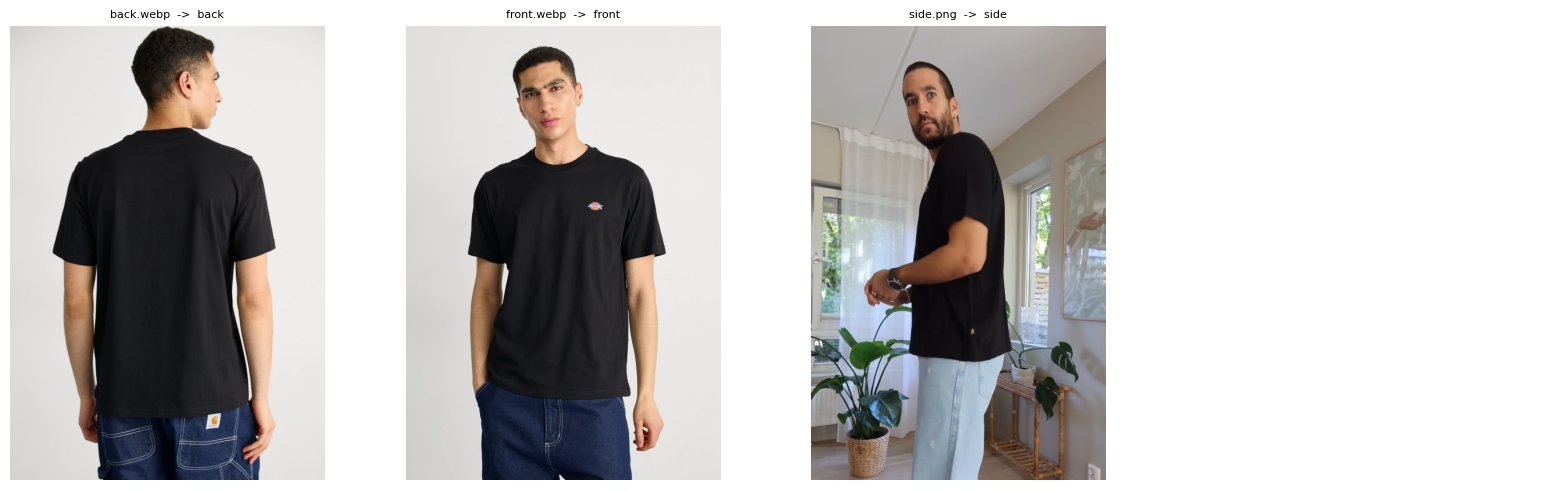

In [71]:
import glob
import matplotlib.pyplot as plt

CLOTHES_ROOT = "/content/clothes/cloth_from_zalando_website"

# One catalogue photograph per orientation class (thesis 4.5), per garment.
E2_GARMENTS = {
    "pier-one-blue": ("pier-one-t-shirt-z-nadrukiem-blue-pi922o06a-k11", {
        "front": "e19d02303035487b9d418bb94adf1ef5.webp",   # flat-lay packshot
        "back":  "d7caa0e46d5e4a94822a1285da83c046.webp",   # on model
        "side":  "d5887522408e4ac796bd83855538f7a0.webp",   # on model, three-quarter: the most lateral view listed
    }),
    "dickies-black": ("dickies-t-shirt-basic-black-di622o037-q11", {
        "front": "front.webp", "back": "back.webp", "side": "side.png",
    }),
    "urban-classics-black": ("urban-classics-t-shirt-basic-black-ur622o03j-q11", {
        "front": "front.webp", "back": "back.webp",
        "side":  "size.png",                                 # the profile photograph, despite its name
    }),
}
GARMENT_E2 = "dickies-black"     # then "dickies-black", then "urban-classics-black"

GARMENT_E2_FOLDER = f"{CLOTHES_ROOT}/{E2_GARMENTS[GARMENT_E2][0]}"
chosen = {name: view for view, name in E2_GARMENTS[GARMENT_E2][1].items()}
photos = sorted(p for ext in ("webp", "jpg", "jpeg", "png")
                for p in glob.glob(f"{GARMENT_E2_FOLDER}/*.{ext}"))
print(f"{GARMENT_E2}: {len(photos)} photograph(s) in {os.path.basename(GARMENT_E2_FOLDER)}")
cols = 4
rows = max(1, -(-len(photos) // cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, p in zip(axes.ravel(), photos):
    name = os.path.basename(p)
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(f"{name}  ->  {chosen[name]}" if name in chosen else name, fontsize=8)
plt.tight_layout()
plt.show()

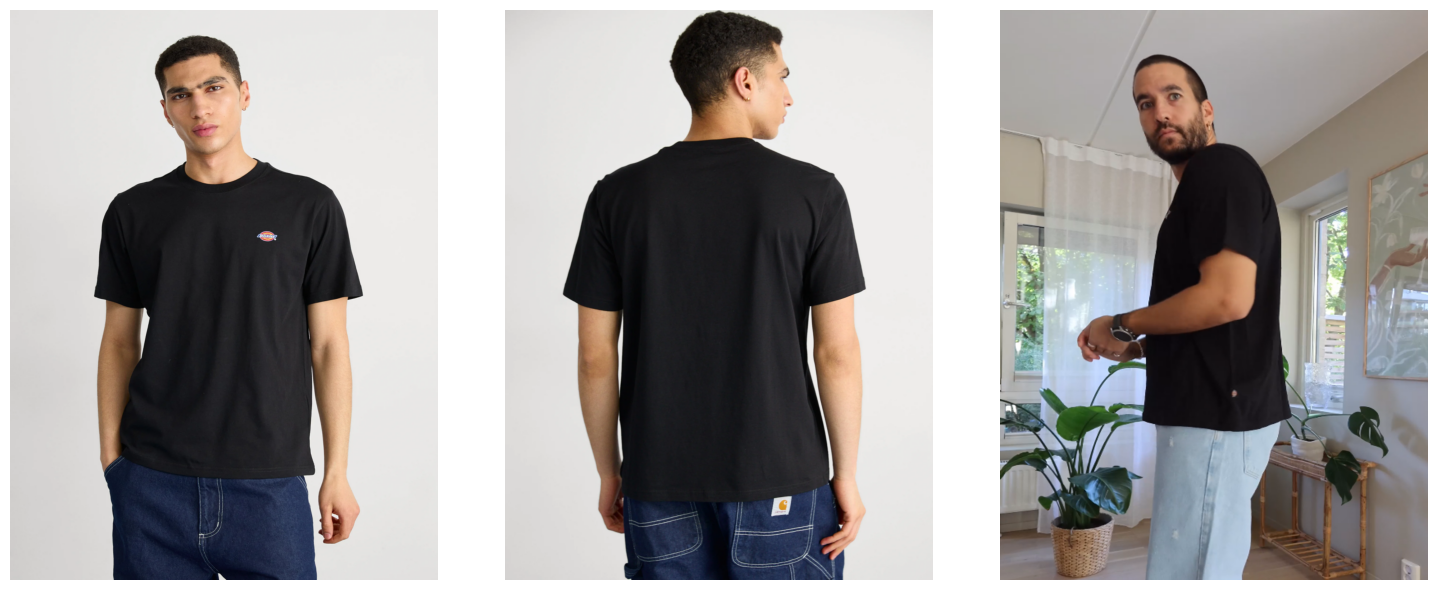

run dir: /content/drive/MyDrive/weavella/runs_2d/vadim__dickies-black__released | full orbit


In [72]:
_folder, _files = E2_GARMENTS[GARMENT_E2]
e2_paths = {view: f"{CLOTHES_ROOT}/{_folder}/{name}" for view, name in _files.items()}
if sorted(e2_paths) != ["back", "front", "side"] or len(set(e2_paths.values())) != 3:
    raise ValueError(
        "E2 needs three distinct photographs, one per orientation class (thesis 4.5); conditioning "
        "lateral frames on the front or back photograph runs the method outside that input.")
for p in e2_paths.values():
    if not os.path.exists(p):
        raise FileNotFoundError(p)

garments_e2 = {view: Image.open(p).convert("RGB").resize(target_size) for view, p in e2_paths.items()}

from vton2d import catalogue_garment_region, garment_region

def catalogue_parse(photo):
    """Garment region of a catalogue photograph and how it was found (vton2d.catalogue_garment_region).

    No person in the photograph (a flat-lay packshot): the white-backdrop cut. A person: the pixels
    both human parsers agree are upper clothes, which keeps bare arms out of the region.
    """
    try:
        res = automasker(photo)
    except Exception as exc:
        print(f"  parse failed ({type(exc).__name__}: {exc}); the backdrop heuristic will be used")
        return garment_region(photo, None, return_source=True)
    return catalogue_garment_region(photo, res["densepose"], res["schp_lip"], res["schp_atr"])

USE_FULL_ORBIT = True     # True: all 58 frames, ~65 min, and 24 dorsal frames for washout.
                          # False: the 17-frame arc only, ~20 min, for a first look.
cfg_e2 = cfg.variant_of(f"{SUBJECT}__{GARMENT_E2}__released", garment=GARMENT_E2,
                        notes="E2: dark garment, released configuration",
                        extra={"garment_folder": _folder, "garment_photos": dict(_files)})
E2_RUN = f"{RUNS_ROOT}/{cfg_e2.run_id}"

show_multiple_images([garments_e2["front"], garments_e2["back"], garments_e2["side"]])
print("run dir:", E2_RUN, "|", "full orbit" if USE_FULL_ORBIT else "17-frame arc")

In [73]:
from vton2d import ensure_garment_masks

frames_e2 = frames_by_view if USE_FULL_ORBIT else SUB
s = ensure_orbit(frames_e2, garments_e2, references, tryon_fn, cfg_e2, RUNS_ROOT,
                 parse_steps_for=2, configure_fn=configure_from, verbose=False)
print(f"{cfg_e2.run_id}: generated {s['generated']}, reused {s['reused']}")

# The garment region of each of the three photographs, stored with the run. Parsing only, seconds.
ensure_garment_masks(E2_RUN, catalogue_parse)

vadim__dickies-black__released: generated 0, reused 58


{'front': 'present', 'side': 'present', 'back': 'present'}

In [74]:
from vton2d import ensure_garment_masks, garment_lookup

# Every E2 garment whose run is on Drive, so switching GARMENT_E2 to generate the next garment never
# replaces an earlier garment's report in this cell's output. Regions are recomputed every time (three
# parser calls per garment), so a change of the region rule cannot leave stale files behind; detail is
# normalised over them, because on these photographs the backdrop cut would take the whole frame.
reports_e2 = {}
for g in E2_GARMENTS:
    rd = f"{RUNS_ROOT}/{SUBJECT}__{g}__released"
    if not os.path.exists(f"{rd}/manifest.json"):
        continue
    ensure_garment_masks(rd, catalogue_parse, refresh=True)
    gfor, mfor = garment_lookup(rd, require_masks=True)
    reports_e2[g] = report_run(rd, garment_for=gfor, garment_mask_for=mfor)
    parse_finals(rd, lambda img: automasker(img)["densepose"], verbose=False)
    body_distortion(rd)
res_e2 = reports_e2.get(GARMENT_E2)

  vadim__pier-one-blue__released/garment/front_mask.png   no person: backdrop heuristic, 37% of the photograph
  vadim__pier-one-blue__released/garment/side_mask.png   parsed: LIP and ATR agree, 25% of the photograph
  vadim__pier-one-blue__released/garment/back_mask.png   parsed: LIP and ATR agree, 24% of the photograph
 RUN  vadim__pier-one-blue__released
 subject / garment  vadim / pier-one-blue
 steps T1 / T2      50 / 50
 guidance           2.5  (reference passes of front at 5.0)
 mask variant       composition   dilation 14 px
 injection          decoder   window [5, 45]
 seed / resolution  42 / (768, 1024)
 written / commit   2026-09-13T14:20:14+00:00 / 5a47a2f5
 notes              E2: dark garment, released configuration

 FRAMES  58    back 24   front 29   side 5

----------------------------------------------------------------
 CROSS-VIEW CONSISTENCY   (Section 5.2.3, lower is better)
----------------------------------------------------------------
 mean 0.3874    median 0.30

### Washout by orientation class

§6.2's washout is a garment rendered lighter and less saturated than the one requested, on dorsal
views. `colour_by_class` measures it against the photograph each class was conditioned on, over the
stored garment regions:

* **dV**, **dS**: median value and saturation of the rendered garment minus the photograph's (0–255),
  a shift of the whole garment.
* **lighter**, **greyer**: share of garment pixels lighter than the photograph's lightest 5 %, or
  greyer than its greyest 5 % — patches, which leave the medians where they were.

Read each garment on its own, dorsal against frontal (`back-front`). Capture lighting differs from
catalogue lighting, so no class sits at zero, and the light garment has little headroom to lighten or
desaturate, so its rows are context rather than a control. The second pair of tables scores the
Phase-1 output over the same region, for §6.2's statement that the refinement pass makes dorsal frames
worse than the coarse pass left them.

**Regions.** A photograph with no person (a flat-lay packshot) uses the white-backdrop cut; an
on-model photograph uses the pixels both human parsers agree are upper clothes. In the darkened panels
only the garment should stay bright.

  vadim__north-face-retro-earth-tee__released/garment/front_mask.png   parsed: LIP and ATR agree, 29% of the photograph
  vadim__north-face-retro-earth-tee__released/garment/side_mask.png   parsed: LIP and ATR agree, 10% of the photograph
  vadim__north-face-retro-earth-tee__released/garment/back_mask.png   parsed: LIP and ATR agree, 25% of the photograph
  vadim__pier-one-blue__released/garment/front_mask.png   no person: backdrop heuristic, 37% of the photograph
  vadim__pier-one-blue__released/garment/side_mask.png   parsed: LIP and ATR agree, 25% of the photograph
  vadim__pier-one-blue__released/garment/back_mask.png   parsed: LIP and ATR agree, 24% of the photograph
  vadim__dickies-black__released/garment/front_mask.png   parsed: LIP and ATR agree, 25% of the photograph
  vadim__dickies-black__released/garment/side_mask.png   parsed: LIP and ATR agree, 11% of the photograph
  vadim__dickies-black__released/garment/back_mask.png   parsed: LIP and ATR agree, 30% of the photograph


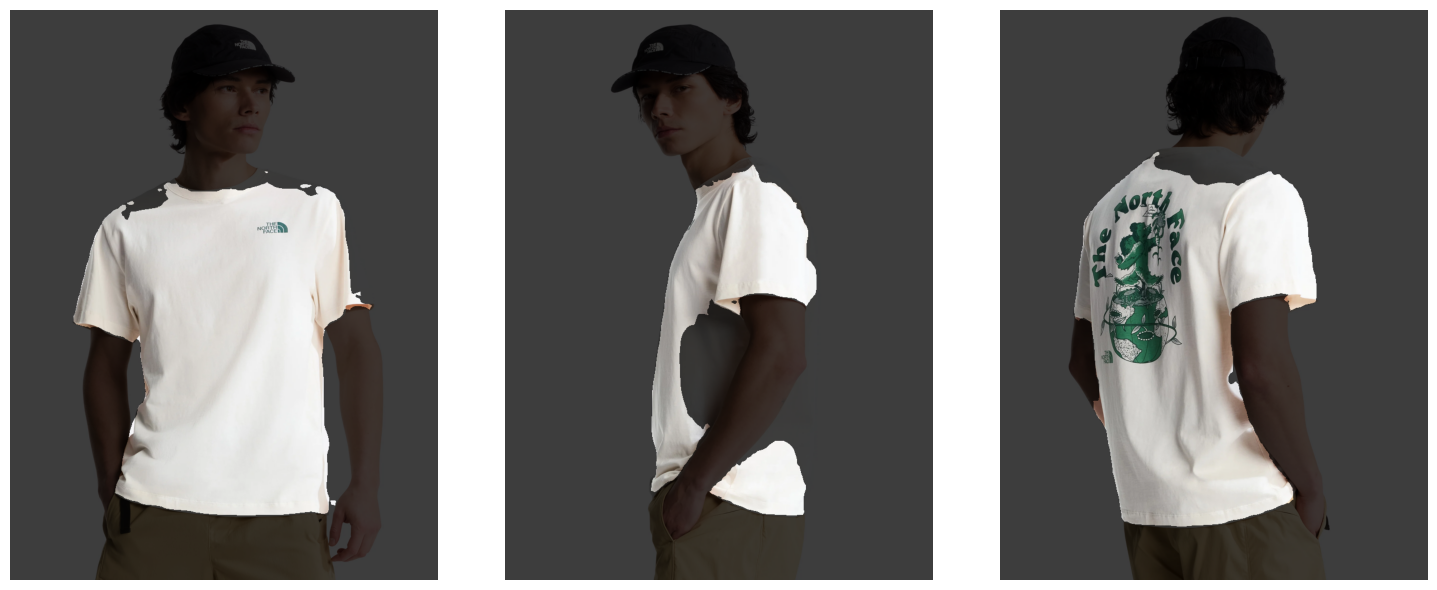

vadim__pier-one-blue__released


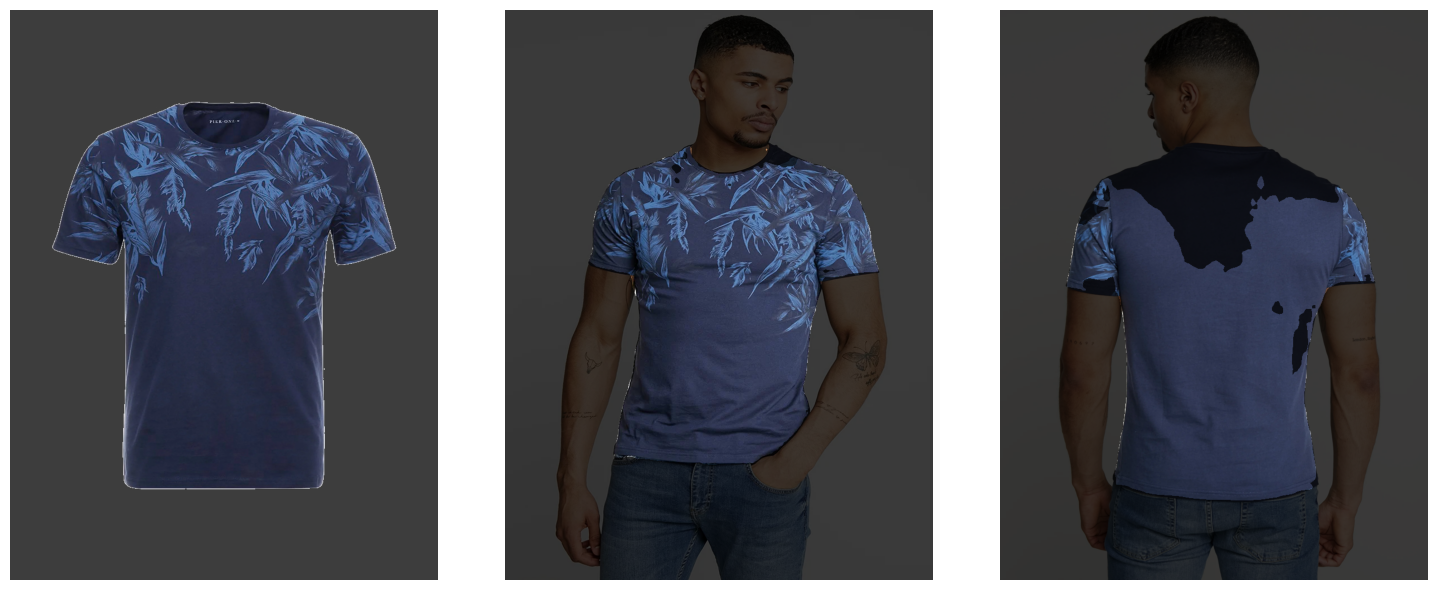

vadim__dickies-black__released


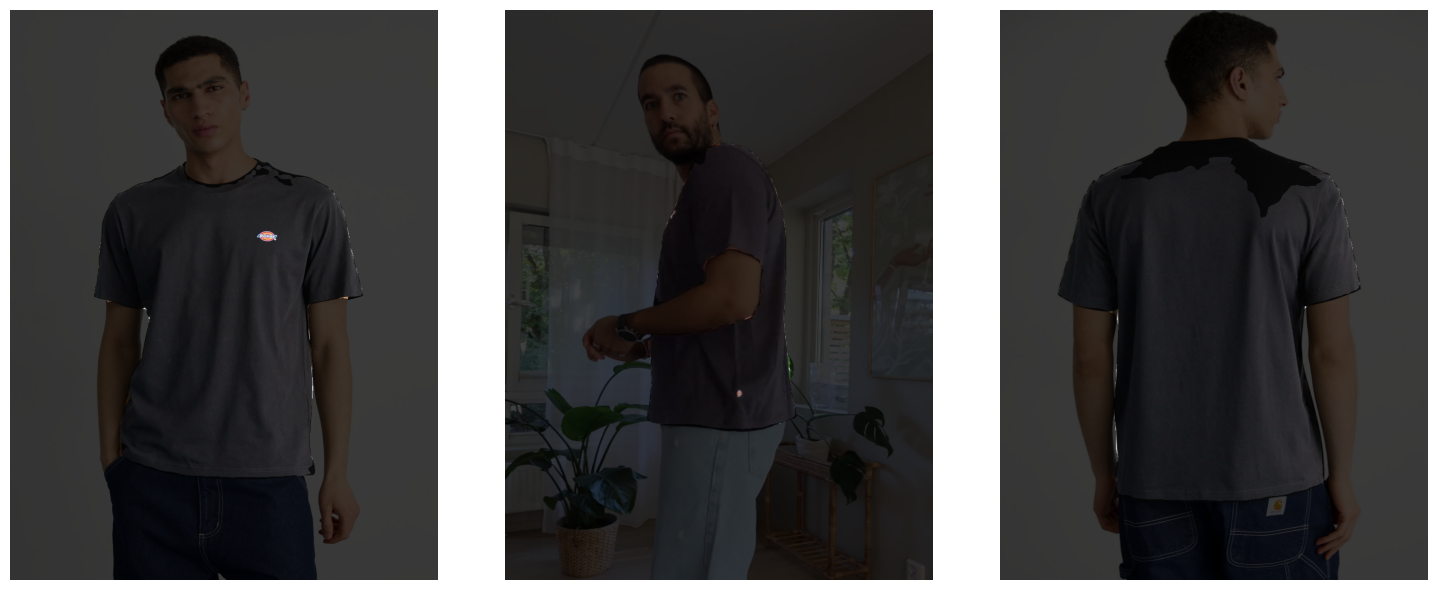

3 garments over the 58 frames they share

vadim__north-face-retro-earth-tee__released   (final, 58 frames, garment north-face-retro-earth-tee)
  class     n      dV      dS  fidelity  lighter  greyer   mostly lighter   V frame/photo   S frame/photo
  front    29   -20.0   +10.0     0.431     0.0%    0.0%     0 (max   3%)     204 / 224       16 / 6    
  side      5   +11.0    +9.0     0.595     0.0%    0.0%     0 (max   0%)     232 / 221       18 / 9    
  back     24   -18.5    +8.0     0.393     0.0%    0.0%     0 (max   1%)     170 / 189       18 / 10   
  back-front     +1.5    -2.0    -0.039    -0.0%   +0.0%
  lighter / greyer: share of garment pixels lighter than the photograph's lightest 5 %, greyer than its greyest 5 %
  mostly lighter: frames in which over half the garment is lighter than that, and the largest share in any frame
vadim__pier-one-blue__released   (final, 58 frames, garment pier-one-blue)
  class     n      dV      dS  fidelity  lighter  greyer   mostly lighter  

In [75]:
from vton2d import colour_by_class, ensure_garment_masks, load_run
import numpy as np

# The light garment and every complete E2 run on Drive, in one output: switching GARMENT_E2 to generate
# the next garment never replaces an earlier garment's tables. A run still being generated is skipped,
# since it would shrink the shared frames and change every garment's numbers.
n_orbit = len(load_run(RELEASED_RUN)["frames"])
washout_runs = [RELEASED_RUN]
for g in E2_GARMENTS:
    rd = f"{RUNS_ROOT}/{SUBJECT}__{g}__released"
    if not os.path.exists(f"{rd}/manifest.json"):
        continue
    n = len(load_run(rd)["frames"])
    if n < n_orbit:
        print(f"skipping {g}: {n} of {n_orbit} frames generated")
        continue
    washout_runs.append(rd)

# Regions recomputed every time, for the same reason as in the report cell.
for rd in washout_runs:
    ensure_garment_masks(rd, catalogue_parse, refresh=True)

# Look at the regions before trusting a number taken over them: everything outside is darkened.
for rd in washout_runs:
    panels = []
    for view in ("front", "side", "back"):
        photo = np.asarray(Image.open(f"{rd}/garment/{view}.png").convert("RGB")).copy()
        region = np.asarray(Image.open(f"{rd}/garment/{view}_mask.png")) > 0
        photo[~region] = (photo[~region] * 0.25).astype(np.uint8)
        panels.append(Image.fromarray(photo))
    print(os.path.basename(rd))
    show_multiple_images(panels)

shared = sorted(set.intersection(*(set(load_run(rd)["frames"]) for rd in washout_runs)))
print(f"{len(washout_runs)} garments over the {len(shared)} frames they share")
print()
washout = {rd: colour_by_class(rd, frames=shared) for rd in washout_runs}

# The Phase-1 output over the same region: only the pass differs from the tables above.
print()
washout_coarse = {rd: colour_by_class(rd, frames=shared, stage="coarse") for rd in washout_runs}

frames ['0045', '0046', '0047', '0048']   worst pair 0046 -> 0047   distance 0.913


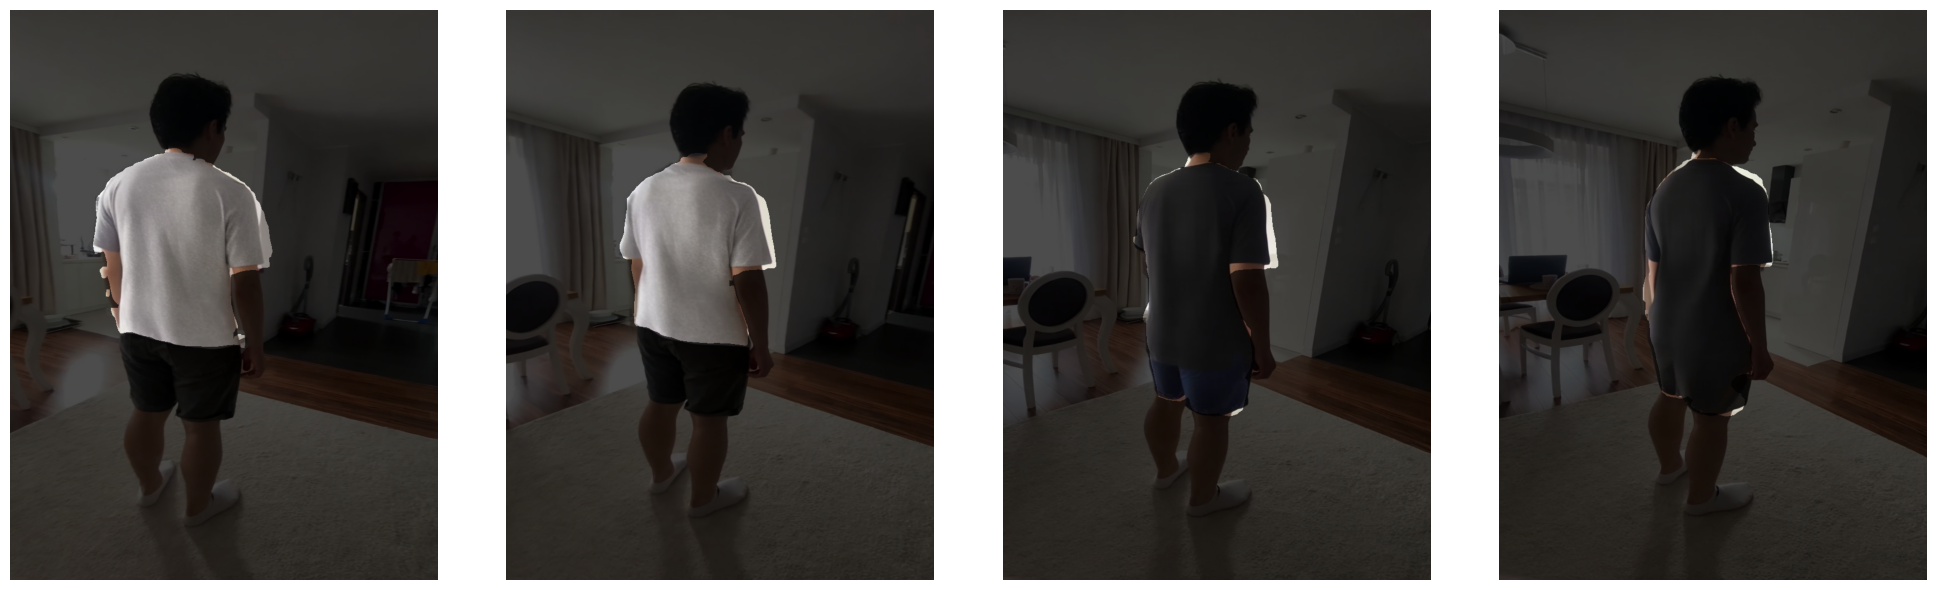

In [76]:
# The largest adjacent-pair distance of the E2 run, with a neighbour on each side: a colour jump in
# the rendering, or a garment mask that caught something other than the garment?
from vton2d import load_run
import numpy as np

_r = load_run(E2_RUN)
_i, _j = res_e2["consistency"]["argmax_pair"]
_names = res_e2["frames"][max(0, _i - 1): _j + 2]
_panels = []
for n in _names:
    img = np.asarray(Image.open(_r["path"]("final", n)).convert("RGB")).copy()
    m = np.asarray(Image.open(_r["path"]("cloth_mask", n)).convert("L").resize(img.shape[1::-1])) > 127
    img[~m] = (img[~m] * 0.3).astype(np.uint8)
    _panels.append(Image.fromarray(img))
print("frames", _names, "  worst pair", res_e2["frames"][_i], "->", res_e2["frames"][_j],
      f"  distance {res_e2['consistency']['max']:.3f}")
show_multiple_images(_panels)

## E5: guidance on the navy garment (thesis §6.2)

The released configuration raises guidance for one pass only, the frontal reference (5.0). The dorsal
reference, every lateral frame and every target run at 2.5, and targets inherit the activations of
their class's reference. In the first E2 run the dorsal class of the navy garment lost far more
saturation than the frontal class, but the lateral frames — at 2.5 like the dorsal ones, and halfway
between front and back in angle — lost nearly as much. Viewpoint and guidance move together in the
released configuration, so E2 alone cannot say which of the two the dorsal loss follows.

Each arm regenerates one orientation class and changes one thing:

| arm | class | change | question |
|---|---|---|---|
| `back_ref5` | dorsal | dorsal reference at 5.0, like the frontal one | does dorsal colour follow its reference's guidance? |
| `front_ref25` | frontal | frontal reference at 2.5, like the dorsal one | the mirror of the above |
| `side_5` | lateral | every lateral frame at 5.0 | lateral frames are their own references |
| `back_g4`, `back_g6` | dorsal | every dorsal pass at 4.0 / 6.0 | the sweep §6.2 promises |

The released run of the same garment is the 2.5 arm of every comparison, over the same frames. §6.2
also says raised guidance costs grain across the whole canvas, face and background included:
`outside_change_by_class` compares the delivered frame with its input outside the composition mask.

About 28 minutes per dorsal arm, 33 for the frontal arm and 6 for the lateral one. `E5_RUN_ARMS` runs
them in the order listed; the first three settle the question of guidance against viewpoint.

In [77]:
from vton2d import ensure_garment_masks

E5_GARMENT = "dickies-black"
E5_BASE = f"{RUNS_ROOT}/{SUBJECT}__{E5_GARMENT}__released"      # its E2 run is the 2.5 arm
_folder5, _files5 = E2_GARMENTS[E5_GARMENT]
garments_e5 = {view: Image.open(f"{CLOTHES_ROOT}/{_folder5}/{name}").convert("RGB").resize(target_size)
               for view, name in _files5.items()}

# (class, overrides). Order is priority.
E5_ARMS = {
    "back_ref5":   ("back",  dict(ref_guidance_views=("front", "back"))),   # dorsal reference at 5.0
    "front_ref25": ("front", dict(ref_guidance_views=())),                  # frontal reference at 2.5
    "side_5":      ("side",  dict(ref_guidance_views=("front", "side"))),   # every lateral frame at 5.0
    "back_g4":     ("back",  dict(guidance_scale=4.0)),                     # every dorsal pass at 4.0
    "back_g6":     ("back",  dict(guidance_scale=6.0)),                     # every dorsal pass at 6.0
}
E5_RUN_ARMS = list(E5_ARMS)       # trim this list to run fewer arms

e5_runs = {}
for tag in E5_RUN_ARMS:
    view, overrides = E5_ARMS[tag]
    c = cfg.variant_of(f"{SUBJECT}__{E5_GARMENT}__e5_{tag}", garment=E5_GARMENT,
                       notes=f"E5: {view} class only, {tag}",
                       extra={"garment_folder": _folder5, "garment_photos": dict(_files5)}, **overrides)
    refs = {view: references[view]} if references.get(view) else {}
    s = ensure_orbit({view: frames_by_view[view]}, garments_e5, refs, tryon_fn, c, RUNS_ROOT,
                     parse_steps_for=0, configure_fn=configure_from, verbose=False)
    ensure_garment_masks(s["run_dir"], catalogue_parse, refresh=True, verbose=False)
    e5_runs[tag] = str(s["run_dir"])
    print(f"{c.run_id}: generated {s['generated']}, reused {s['reused']}")

LF-MA mode='decoder' window=(5, 45): 9 of 32 attention layers carry injection
Phase 1: Coarse mask + try-on...


  0%|          | 0/50 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 50/50 [00:19<00:00,  2.55it/s]


Phase 2: Refining Mask from Coarse Result...
  -> Selecting LIP upper-clothes mask (larger area: 92689 vs 91725)
  -> Selecting LIP upper-clothes mask (larger area: 95879 vs 93264)
Phase 2: Paste-back composite...
Phase 3: Refine try-on...


  0%|          | 0/50 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 50/50 [00:12<00:00,  3.93it/s]


Phase 1: Coarse mask + try-on...


...

Phase 1: Coarse mask + try-on...


  0%|          | 0/50 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 50/50 [00:13<00:00,  3.71it/s]


Phase 2: Refining Mask from Coarse Result...
  -> Selecting LIP upper-clothes mask (larger area: 72639 vs 67132)
  -> Selecting ATR upper-clothes mask (larger area: 42744 vs 39504)
Phase 2: Paste-back composite...
Phase 3: Refine try-on...


  0%|          | 0/50 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
100%|██████████| 50/50 [00:13<00:00,  3.71it/s]


vadim__dickies-black__e5_back_g6: generated 24, reused 0


In [78]:
from vton2d import (colour_by_class, compare_runs, ensure_garment_masks, garment_lookup, load_run,
                    outside_change_by_class)
import json

# Every arm on disk, including any run in an earlier session.
e5_runs = {tag: f"{RUNS_ROOT}/{SUBJECT}__{E5_GARMENT}__e5_{tag}" for tag in E5_ARMS
           if os.path.exists(f"{RUNS_ROOT}/{SUBJECT}__{E5_GARMENT}__e5_{tag}/manifest.json")}
ensure_garment_masks(E5_BASE, catalogue_parse, refresh=True, verbose=False)
gfor5, mfor5 = garment_lookup(E5_BASE, require_masks=True)

COLOUR = ("d_value", "d_saturation", "fidelity", "lighter_share", "greyer_share")
OUTSIDE = ("grain_ratio", "abs_diff", "d_saturation")

def fmt(key, x):
    if x is None:
        return "     -"
    if key.endswith("share"):
        return f"{x:6.1%}"
    if key in ("fidelity", "grain_ratio"):
        return f"{x:6.3f}"
    return f"{x:+6.1f}"

e5_table = {}
print("released -> arm, each over the arm's own frames")
print(f"{'arm':<12}{'class':<7}{'n':>3}  " + "  ".join(f"{k:>16}" for k in COLOUR)
      + "  " + "  ".join(f"{'out ' + k:>16}" for k in OUTSIDE))
for tag, rd in e5_runs.items():
    view = E5_ARMS[tag][0]
    frames = load_run(rd)["frames"]
    base = colour_by_class(E5_BASE, frames=frames, verbose=False)["by_class"].get(view, {})
    arm = colour_by_class(rd, frames=frames, verbose=False)["by_class"].get(view, {})
    base_out = outside_change_by_class(E5_BASE, frames=frames, verbose=False)["by_class"].get(view, {})
    arm_out = outside_change_by_class(rd, frames=frames, verbose=False)["by_class"].get(view, {})
    e5_table[tag] = {"class": view, "base": base, "arm": arm,
                     "base_outside": base_out, "arm_outside": arm_out}
    cells = [f"{fmt(k, base.get(k))} ->{fmt(k, arm.get(k))}" for k in COLOUR]
    cells += [f"{fmt(k, base_out.get(k))} ->{fmt(k, arm_out.get(k))}" for k in OUTSIDE]
    print(f"{tag:<12}{view:<7}{arm.get('n', 0):>3}  " + "  ".join(f"{c:>16}" for c in cells))

# Consistency and detail inside the dorsal class, for the arms that regenerate it.
back_arms = [rd for tag, rd in e5_runs.items() if E5_ARMS[tag][0] == "back"]
rows_e5 = []
if back_arms:
    print()
    rows_e5 = compare_runs([E5_BASE] + back_arms, axes=("guidance_scale", "ref_guidance_views"),
                           garment_for=gfor5, garment_mask_for=mfor5)

with open(f"{RUNS_ROOT}/e5_guidance.json", "w") as fh:
    json.dump({"arms": e5_table, "dorsal_rows": rows_e5}, fh, indent=2, default=str)
print(f"saved to {RUNS_ROOT}/e5_guidance.json")

released -> arm, each over the arm's own frames
arm         class    n           d_value      d_saturation          fidelity     lighter_share      greyer_share   out grain_ratio      out abs_diff  out d_saturation
back_ref5   back    24   +125.0 ->+117.0    -19.0 -> -23.5    0.899 -> 0.895    95.6% -> 94.8%    43.3% -> 58.9%    0.928 -> 0.929     +2.6 ->  +2.6     +1.0 ->  +1.0
front_ref25 front   29     -3.0 -> +42.0    +12.0 ->  +3.0    0.883 -> 0.888    13.4% -> 74.8%    10.1% ->  4.6%    0.927 -> 0.924     +2.9 ->  +2.9     +1.0 ->  +1.0
side_5      side     5   +100.0 ->+163.0    -36.0 -> -11.0    0.961 -> 0.938    98.6% -> 98.0%    82.1% -> 22.4%    0.943 -> 1.017     +3.2 ->  +5.8     +1.0 ->  +0.0
back_g4     back    24   +125.0 ->+126.5    -19.0 -> -24.0    0.899 -> 0.876    95.6% -> 93.6%    43.3% -> 59.4%    0.928 -> 0.912     +2.6 ->  +3.1     +1.0 ->  +1.0
back_g6     back    24   +125.0 ->+139.5    -19.0 -> -22.0    0.899 -> 0.881    95.6% -> 93.2%    43.3% -> 55.0%    0

In [79]:
from vton2d import body_width_shift, load_run

arc_frames = sorted(set(load_run(e8[0])["frames"]))
print("like-for-like on the arc:")
body_distortion(RELEASED_RUN, frames=arc_frames)

r = load_run(RELEASED_RUN)
rows = []
for n in sorted(r["frames"]):
    shift = body_width_shift(r["path"]("final_densepose", n), r["path"]("densepose", n))
    if shift:
        rows.append((shift["abs_median_pct"], n))
rows.sort()

print("\nworst 6 frames:")
for pct, n in rows[-6:]:
    print(f"  {n}  {pct:5.1f}%  ({view_of.get(n, '?')})")
print("best 6 frames:")
for pct, n in rows[:6]:
    print(f"  {n}  {pct:5.1f}%  ({view_of.get(n, '?')})")

import numpy as np
for cls in ("front", "side", "back"):
    vals = [pct for pct, n in rows if view_of.get(n) == cls]
    if vals:
        print(f"{cls:>6}: median {np.median(vals):5.1f}%   max {max(vals):5.1f}%   n={len(vals)}")

like-for-like on the arc:
vadim__north-face-retro-earth-tee__released    body width  signed   +1.4%   absolute  11.9%   worst  35.8%   over 17 frames

worst 6 frames:
  0049   29.8%  (back)
  0021   29.8%  (front)
  0057   31.1%  (front)
  0031   32.2%  (back)
  0058   32.6%  (front)
  0023   35.8%  (front)
best 6 frames:
  0016    0.6%  (front)
  0027    1.6%  (side)
  0007    2.2%  (front)
  0041    2.2%  (back)
  0035    2.7%  (back)
  0014    3.0%  (front)
 front: median   8.0%   max  35.8%   n=29
  side: median   5.6%   max   8.1%   n=5
  back: median  12.8%   max  32.2%   n=24


In [80]:
# Self-contained. This cell used to borrow d, names and v from an earlier cell, and a later cell
# reused v as a loop variable, so running the notebook top to bottom crashed here.
from vton2d import load_scores
import numpy as np

_scores = load_scores(RELEASED_RUN)
dist = np.array(_scores["consistency"]["distances"])
frame_names = _scores["frames"]
view_by_frame = _scores["view_of"]

# One distance per adjacent pair. consistency_series skips frames whose mask is empty, and if any
# were skipped this index alignment would silently pair the wrong frames.
assert len(dist) == len(frame_names) - 1, (
    f"{len(dist)} distances for {len(frame_names)} frames - some frames were skipped, "
    f"so pairs cannot be indexed by position")

side_pairs = [i for i in range(len(dist))
              if "side" in (view_by_frame[frame_names[i]], view_by_frame[frame_names[i + 1]])]
other = [i for i in range(len(dist)) if i not in side_pairs]
print(f"pairs touching a side frame : n={len(side_pairs):>2}  mean {dist[side_pairs].mean():.4f}")
print(f"all other pairs             : n={len(other):>2}  mean {dist[other].mean():.4f}")
print(f"ratio {dist[side_pairs].mean() / dist[other].mean():.2f}x   (boundary split was 2.27x)")


pairs touching a side frame : n= 7  mean 0.4533
all other pairs             : n=50  mean 0.2108
ratio 2.15x   (boundary split was 2.27x)


# 3D Part

### Copy try-on results folder to Google Drive

In [ ]:
!mkdir -p /content/drive/MyDrive/weavella/try_on_results
!tar -cf /content/drive/MyDrive/weavella/try_on_results/2_phase_vadim_2fps_pier-one-t-shirt-z-nadrukiem-blue-pi922o06a-k11.tar \
    -C /content/gaussian-splatting/input/vadim/try_on_res input

## Download try-on results from Google Drive

In [ ]:
!mkdir -p /content/try_on_results
!gdown 1JMdPFAw8tWM4eGDOoMIqAOTE2wsgemBS \
    -O /content/try_on_results/2_phase_vadim_2fps_the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11.tar

In [ ]:
# unpack try-on result images
!mkdir -p /content/gaussian-splatting/input/vadim/try_on_res/input
!tar -xf /content/try_on_results/2_phase_vadim_2fps_the-north-face-retro-earth-short-sleeve-graphic-t-shirt-z-nadrukiem-white-dune-th322o0e8-a11.tar \
    --strip-components=1 \
    -C /content/gaussian-splatting/input/vadim/try_on_res/input

## Run 3DGS training

### Install GPU-accelerated COLMAP

In [ ]:
# All of these is to use GPU-accelerated version of COLMAP

# Install xvfb for OpenGL virtual display and required dependencies to build COLMAP
!sudo apt-get update
!sudo apt-get install -y xvfb cmake ninja-build \
    libboost-program-options-dev libboost-filesystem-dev libboost-graph-dev \
    libboost-system-dev libboost-test-dev libsuitesparse-dev \
    libfreeimage-dev libgoogle-glog-dev libgflags-dev \
    libglew-dev libqt5opengl5-dev qt5-qmake qtbase5-dev libceres-dev \
    libflann-dev libcgal-dev libmetis-dev

# Build COLMAP from source for GPU (CUDA) support
!rm -rf /content/colmap
!git clone --branch 3.9 https://github.com/colmap/colmap.git /content/colmap
%cd /content/colmap
!mkdir build
%cd build
!cmake .. -GNinja -DCUDA_ENABLED=ON -DCMAKE_BUILD_TYPE=Release -DCMAKE_CUDA_ARCHITECTURES=native
!ninja
!sudo ninja install

### Create 3DGS model of vanila vadim

#### Run COLMAP

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim/vanilla/input
!ffmpeg -i /content/gaussian-splatting/input/vadim/vadim.MOV -qscale: 1 -qmin 1 -vf fps=2 /content/gaussian-splatting/input/vadim/vanilla/input/%04d.jpg

In [ ]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/vanilla

In [ ]:
!mkdir -p /content/drive/MyDrive/weavella/3DGS_results/COLMAP_results
!tar -cf /content/drive/MyDrive/weavella/3DGS_results/COLMAP_results/vanilla_vadim_COLMAP_2fps_with_bg.tar \
    -C /content/gaussian-splatting/input/vadim vanilla

#### Load COLMAP from Google Drive

In [ ]:
!mkdir -p /content/gaussian-splatting/input/vadim/vanilla/
!gdown 1Y6fq0wR5Xs7_X55akFe3Ml_Px65W2tkz -O /content/gaussian-splatting/input/vadim/vanilla/vanilla_vadim_COLMAP_2fps_with_bg.tar

In [ ]:
!tar -xf /content/gaussian-splatting/input/vadim/vanilla/vanilla_vadim_COLMAP_2fps_with_bg.tar \
    --strip-components=1 \
    -C /content/gaussian-splatting/input/vadim/vanilla

### Run 3DGS training on initial frames

In [ ]:
# Start 3DGS training run and save it to a specific model folder (-m)
%cd /content/gaussian-splatting
!python train.py \
    -s /content/gaussian-splatting/input/vadim/vanilla/ \
    -m /content/gaussian-splatting/output/vanilla_vadim_3DGS_with_bg \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

In [ ]:
show_3DGS_loss_curve("/content/gaussian-splatting/output/vanilla_vadim_3DGS_with_bg")

### Remove background from COLMAP images

In [ ]:
target_dir = Path("/content/gaussian-splatting/input/vadim/vanilla/images")
remove_background_from_all_in_dir(target_dir, automasker)

### Run 3DGS training on frames with removed bg, but before try-on

In [ ]:
# Start 3DGS training run and save it to a specific model folder (-m)
%cd /content/gaussian-splatting
!python train.py \
    -s /content/gaussian-splatting/input/vadim/vanilla/ \
    -m /content/gaussian-splatting/output/vanilla_vadim_3DGS_no_bg \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

In [ ]:
show_3DGS_loss_curve("/content/gaussian-splatting/output/vanilla_vadim_3DGS_no_bg")

In [ ]:
!tar -cf /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim_3DGS_2fps_no_bg.tar \
    -C /content/gaussian-splatting/output vanilla_vadim_3DGS_no_bg

In [ ]:
# Copy the specific training output folder to Google Drive
# !cp -r /content/gaussian-splatting/output/vanilla_vadim_3DGS /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_vadim_splat_10fps_no_bg

### Optimize pre-trained 3DGS of vanilla Vadim on Using Try-On Images

Doesn't actually produce better results

In [ ]:
# copy COLMAP created from vanilla frames, since we would have the same camera positions and init points
# -n flag to not replace our try-on images
!cp -rn /content/gaussian-splatting/input/vadim/vanilla/* /content/gaussian-splatting/input/vadim/try_on_res/
# -f flag to force replace/overwrite with our try-on images
!cp -rf /content/gaussian-splatting/input/vadim/try_on_res/input/* /content/gaussian-splatting/input/vadim/try_on_res/images/

In [ ]:
target_dir = Path("/content/gaussian-splatting/input/vadim/try_on_res/images")
remove_background_from_all_in_dir(target_dir, automasker)

In [ ]:
# --- RESUME 3DGS FROM VANILLA to optimize on actual try-oned images now ---
%cd /content/gaussian-splatting

# Fix PyTorch weights_only strict loading issue in train.py
!sed -i 's/torch.load(checkpoint)/torch.load(checkpoint, weights_only=False)/g' /content/gaussian-splatting/train.py

In [ ]:
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS \
    --start_checkpoint /content/gaussian-splatting/output/vanilla_vadim_3DGS_no_bg/chkpnt30000.pth \
    --checkpoint_iterations 37000 60000 \
    --iterations 60000

In [ ]:
show_3DGS_loss_curve("/content/gaussian-splatting/output/vanilla_optimized_try_on_vadim_3DGS")

In [ ]:
!tar -cf /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vanilla_optimized_try_on_vadim_3DGS_2fps_no_bg_v2.tar \
    -C /content/gaussian-splatting/output vanilla_optimized_try_on_vadim_3DGS

### Train 3DGS on try-oned images

#### Create COLMAP from try-on images

In [ ]:
%cd /content/gaussian-splatting

# Run COLMAP conversion using xvfb-run to provide a virtual display for OpenGL
!xvfb-run python convert.py -s /content/gaussian-splatting/input/vadim/try_on_res

In [ ]:
target_dir = Path("/content/gaussian-splatting/input/vadim/try_on_res/images")
remove_background_from_all_in_dir(target_dir, automasker)

In [ ]:
# Start 3DGS training run and save it to a specific model folder (-m)
%cd /content/gaussian-splatting
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on_3DGS_with_COLMAP_from_try_on_imgs \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

In [ ]:
show_3DGS_loss_curve("/content/gaussian-splatting/output/vadim_try_on_3DGS_with_COLMAP_from_try_on_imgs")

In [ ]:
!tar -cf /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/all_splats_02_06_night.tar \
    -C /content/gaussian-splatting output

In [ ]:
# Copy the specific training output folder to Google Drive
!tar -cf /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vadim_try_on_2_phase_2fps_with_COLMAP_from_try_on_imgs_3DSG_30k_iter.tar \
    -C /content/gaussian-splatting/output vadim_try_on_3DGS_with_COLMAP_from_try_on_imgs

#### Reuse COLMAP from initial frames
Worse visual results for some reason (but loss it better (smaller))

In [ ]:
# copy COLMAP created from vanilla frames, since we would have the same camera positions and init points
# -n flag to not replace our try-on images
!cp -rn /content/gaussian-splatting/input/vadim/vanilla/* /content/gaussian-splatting/input/vadim/try_on_res/
# -f flag to force replace/overwrite with our try-on images
!cp -rf /content/gaussian-splatting/input/vadim/try_on_res/input/* /content/gaussian-splatting/input/vadim/try_on_res/images/

In [ ]:
target_dir = Path("/content/gaussian-splatting/input/vadim/try_on_res/images")
remove_background_from_all_in_dir(target_dir, automasker)

In [ ]:
# Start 3DGS training run and save it to a specific model folder (-m)
%cd /content/gaussian-splatting
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on_3DGS \
    --checkpoint_iterations 7000 30000 \
    --iterations 30000

In [ ]:
show_3DGS_loss_curve("/content/gaussian-splatting/output/vadim_try_on_3DGS")

In [ ]:
# --- RESUME 3DGS LATER ---
# Fix PyTorch weights_only strict loading issue in train.py
!sed -i 's/torch.load(checkpoint)/torch.load(checkpoint, weights_only=False)/g' /content/gaussian-splatting/train.py

# If the colab disconnects or you want to train further (e.g., to 40k), you can run:
!python train.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on_3DGS \
    --start_checkpoint /content/gaussian-splatting/output/vadim_try_on_3DGS/chkpnt30000.pth \
    --checkpoint_iterations 100000 \
    --iterations 100000

In [ ]:
# Copy the specific training output folder to Google Drive
!tar -cf /content/drive/MyDrive/weavella/3DGS_results/just_tests_sandbox/vadim_try_on_2_phase_2fps_3DSG_30k_iter.tar \
    -C /content/gaussian-splatting/output vadim_try_on_3DGS

# Freeze Pip versions

In [ ]:
!pip freeze > /content/requirements_locked.txt

# Expert LoRAs Training

### Imports and utility functions

#### Determine body rotation angles from COLMAP

In [ ]:
import os
import math
import json
import shutil
import struct
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

# Diffusers & PEFT
from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict
from transformers import CLIPTextModel, CLIPTokenizer
from accelerate import Accelerator

In [ ]:
# ---------------------------------------------------------------------------
# 1. COLMAP Parsing Utilities
# ---------------------------------------------------------------------------
def qvec2rotmat(qvec):
    return np.array([
        [1 - 2 * qvec[2]**2 - 2 * qvec[3]**2,
         2 * qvec[1] * qvec[2] - 2 * qvec[0] * qvec[3],
         2 * qvec[3] * qvec[1] + 2 * qvec[0] * qvec[2]],
        [2 * qvec[1] * qvec[2] + 2 * qvec[0] * qvec[3],
         1 - 2 * qvec[1]**2 - 2 * qvec[3]**2,
         2 * qvec[2] * qvec[3] - 2 * qvec[0] * qvec[1]],
        [2 * qvec[3] * qvec[1] - 2 * qvec[0] * qvec[2],
         2 * qvec[2] * qvec[3] + 2 * qvec[0] * qvec[1],
         1 - 2 * qvec[1]**2 - 2 * qvec[2]**2]
    ])

def read_images_binary(path_to_model_file):
    """
    Reads the COLMAP images.bin file.
    Returns a dict mapping image_id to image info including name and Q, T.
    """
    images = {}
    with open(path_to_model_file, "rb") as fid:
        num_reg_images = struct.unpack("<Q", fid.read(8))[0]
        for _ in range(num_reg_images):
            binary_image_properties = struct.unpack("<idddddddi", fid.read(64))
            image_id = binary_image_properties[0]
            qvec = np.array(binary_image_properties[1:5])
            tvec = np.array(binary_image_properties[5:8])
            camera_id = binary_image_properties[8]
            image_name = ""
            current_char = struct.unpack("<c", fid.read(1))[0]
            while current_char != b"\x00":   # look for the null \0
                image_name += current_char.decode("utf-8")
                current_char = struct.unpack("<c", fid.read(1))[0]
            num_points2D = struct.unpack("<Q", fid.read(8))[0]
            # Skip 2D points (x, y, point3D_id) = 8 bytes + 8 bytes + 8 bytes = 24 bytes
            fid.seek(num_points2D * 24, 1)

            images[image_id] = {
                "name": image_name,
                "qvec": qvec,
                "tvec": tvec
            }
    return images

def calculate_azimuth(qvec, tvec, centroid=None):
    """
    Calculate the azimuthal angle (in degrees) of the camera relative to the origin.
    If centroid is provided, assumes the subject is centered at the given centroid.
    Camera center C = -R^T * T
    """
    R = qvec2rotmat(qvec)
    C = -np.dot(R.T, tvec)

    if centroid is not None:
        C = C - centroid

    # In COLMAP, standard coordinate system often has Y pointing down, Z forward.
    # The XZ plane is usually the ground plane.
    # Let's compute angle using atan2(x, z). Adjust this mapping if your world orientation differs.
    x, y, z = C
    angle_rad = math.atan2(x, z)
    angle_deg = math.degrees(angle_rad)

    # Normalize to 0-360
    if angle_deg < 0:
        angle_deg += 360
    return angle_deg

# ---------------------------------------------------------------------------
# 2. Dataset Partitioning
# ---------------------------------------------------------------------------

def get_colmap_angles(colmap_images_bin):
    """
    Extracts images from COLMAP and calculates their raw azimuth angles.
    """
    images_info = read_images_binary(colmap_images_bin)

    # Calculate centroid of all cameras
    centers = []
    for info in images_info.values():
        R = qvec2rotmat(info["qvec"])
        C = -np.dot(R.T, info["tvec"])
        centers.append(C)
    centroid = np.mean(centers, axis=0)
    print(f"Calculated camera centroid (new origin): {centroid}")

    # Calculate raw angles
    raw_angles = {}
    for img_id, info in images_info.items():
        raw_angles[info["name"]] = calculate_azimuth(info["qvec"], info["tvec"], centroid)

    return raw_angles

def shift_angles(raw_angles, anchor_image_name=None):
    """
    Shifts all angles so that the anchor_image_name is at 0 degrees.
    """
    shift_angle = 0
    if anchor_image_name and anchor_image_name in raw_angles:
        shift_angle = raw_angles[anchor_image_name]
        print(f"Anchoring front to {anchor_image_name} (Raw Angle: {shift_angle:.2f} deg). Shifting all angles by -{shift_angle:.2f} deg.")

    shifted_angles = {}
    for name, angle in raw_angles.items():
        shifted_angles[name] = (angle - shift_angle) % 360

    return shifted_angles

def create_partitions(shifted_angles, source_image_dir, output_dir):
    """
    Partitions images into Front, Side, and Back folders based on shifted azimuths.
    """
    partitions = {
        "front": [],
        "side": [],
        "back": []
    }

    os.makedirs(os.path.join(output_dir, "front"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "side"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "back"), exist_ok=True)

    for name, angle in shifted_angles.items():
        # Splatting the Cat partitions:
        # Front: -60 to 60 (or 300 to 360 and 0 to 60)
        # Back: 120 to 240
        # Side: 60 to 120, and 240 to 300

        if angle <= 60 or angle >= 300:
            category = "front"
        elif 120 <= angle <= 240:
            category = "back"
        else:
            category = "side"

        partitions[category].append(name)

        # Copy file
        src_path = os.path.join(source_image_dir, name)
        dst_path = os.path.join(output_dir, category, name)
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)

    print(f"\nDataset partitioned: Front({len(partitions['front'])}), Side({len(partitions['side'])}), Back({len(partitions['back'])})")
    for name in sorted(shifted_angles.keys()):
        print(f"Image: {name:<12} | Angle: {shifted_angles[name]:>6.2f} deg")
    return partitions


#### LoRA training function

In [ ]:
import os, random
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from PIL.ImageOps import exif_transpose
from tqdm.auto import tqdm
import torchvision.transforms as T
from diffusers import StableDiffusionInpaintPipeline, DDPMScheduler, AutoencoderKL
from diffusers.optimization import get_scheduler
from peft import LoraConfig, get_peft_model
from transformers import CLIPTextModel, CLIPTokenizer
from accelerate import Accelerator

def make_mask(resolution, times=30):
    """RealFill-style mask (many small boxes). 1 = inpaint region, 0 = keep (context)."""
    mask = torch.ones(1, resolution, resolution)
    times = np.random.randint(1, times)
    min_size, max_size, margin = np.array([0.03, 0.25, 0.01]) * resolution
    max_size = min(max_size, resolution - margin * 2)
    for _ in range(times):
        w = np.random.randint(int(min_size), int(max_size))
        h = np.random.randint(int(min_size), int(max_size))
        x = np.random.randint(int(margin), resolution - int(margin) - w + 1)
        y = np.random.randint(int(margin), resolution - int(margin) - h + 1)
        mask[:, y:y + h, x:x + w] = 0
    if random.random() < 0.5:
        mask = 1 - mask
    return mask

def train_expert_lora(image_folder, output_dir, view_name,
                      rank=8, alpha=16, dropout=0.1, steps=1000,
                      batch_size=4, lr_unet=2e-4, lr_text=4e-5,
                      lr_warmup=100, resolution=512,
                      train_text_encoder=False,            # GS-VTON trains it; see note below
                      model_id="runwayml/stable-diffusion-inpainting"):  # MUST match SDSLoss base
    print(f"\n--- LoRA training: {view_name.upper()} (rank={rank}, steps={steps}) ---")
    accelerator = Accelerator(mixed_precision="fp16")
    device = accelerator.device

    tokenizer    = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
    vae          = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
    unet         = StableDiffusionInpaintPipeline.from_pretrained(model_id, subfolder="unet").unet.to(device)
    scheduler    = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")
    assert scheduler.config.prediction_type == "epsilon"

    vae.requires_grad_(False)
    unet.requires_grad_(False)
    text_encoder.requires_grad_(False)

    # UNet LoRA (q/k/v/out)
    unet = get_peft_model(unet, LoraConfig(
        r=rank, lora_alpha=alpha, lora_dropout=dropout,
        target_modules=["to_q", "to_k", "to_v", "to_out.0"]))
    unet.train()

    param_groups = [{"params": [p for p in unet.parameters() if p.requires_grad], "lr": lr_unet}]
    if train_text_encoder:
        # GS-VTON / RealFill also adapts the text encoder. If you enable this, SDSLoss must
        # additionally load + switch the matching "lora_expert_<view>_text" adapters per view.
        text_encoder = get_peft_model(text_encoder, LoraConfig(
            r=rank, lora_alpha=alpha, lora_dropout=dropout,
            target_modules=["k_proj", "q_proj", "v_proj", "out_proj"]))
        text_encoder.train()
        param_groups.append({"params": [p for p in text_encoder.parameters() if p.requires_grad], "lr": lr_text})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-2)
    lr_sched  = get_scheduler("constant_with_warmup", optimizer=optimizer,
                              num_warmup_steps=lr_warmup, num_training_steps=steps)

    # Load training images once
    paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not paths:
        print(f"No images for {view_name}. Skipping.")
        return []
    print(f"{len(paths)} training images.")
    imgs = [exif_transpose(Image.open(p)).convert("RGB") for p in paths]

    aug = T.Compose([
        T.RandomResizedCrop(resolution, scale=(0.9, 1.0), ratio=(1.0, 1.0)),
        T.ToTensor(),                 # [0, 1]
        T.Normalize([0.5], [0.5]),    # -> [-1, 1]
    ])

    prompt = f"a photo of a {view_name} view person wearing a garment"

    unet, text_encoder, optimizer = accelerator.prepare(unet, text_encoder, optimizer)

    def encode_prompt(use_empty):
        txt = "" if use_empty else prompt
        ids = tokenizer(txt, padding="max_length", truncation=True,
                        max_length=tokenizer.model_max_length, return_tensors="pt").input_ids.to(device)
        if train_text_encoder:
            return text_encoder(ids)[0]
        with torch.no_grad():
            return text_encoder(ids)[0]

    losses = []
    for step in tqdm(range(steps), desc=f"Training {view_name}"):
        optimizer.zero_grad()
        idx = np.random.choice(len(imgs), size=batch_size, replace=True)
        pixels = torch.stack([aug(imgs[i]) for i in idx]).to(device)                          # [B,3,H,W] in [-1,1]
        masks  = torch.stack([make_mask(resolution) for _ in range(batch_size)]).to(device)   # [B,1,H,W]

        # --- CORRECT inpainting conditioning: apply mask in PIXEL space, THEN encode ---
        masked_pixels = pixels * (masks < 0.5)
        with torch.no_grad():
            latents    = vae.encode(pixels).latent_dist.sample()        * vae.config.scaling_factor
            masked_lat = vae.encode(masked_pixels).latent_dist.sample() * vae.config.scaling_factor
        masks_lat = F.interpolate(masks, size=latents.shape[2:])          # mask -> latent resolution

        noise = torch.randn_like(latents)
        t = torch.randint(0, scheduler.config.num_train_timesteps, (batch_size,), device=device).long()
        noisy = scheduler.add_noise(latents, noise, t)

        emb = encode_prompt(use_empty=(random.random() < 0.1))           # 10% CFG (empty-prompt) dropout
        if emb.shape[0] == 1:
            emb = emb.repeat(batch_size, 1, 1)

        model_in = torch.cat([noisy, masks_lat, masked_lat], dim=1)      # 4 + 1 + 4 = 9 channels
        pred = unet(model_in, t, encoder_hidden_states=emb).sample

        loss = F.mse_loss(pred.float(), noise.float())                   # uniform weighting (GS-VTON style)
        accelerator.backward(loss)
        accelerator.clip_grad_norm_(unet.parameters(), 1.0)
        optimizer.step(); lr_sched.step()
        losses.append(loss.item())

    # Save adapters. UNet dir name kept identical so the existing SDSLoss loader still works.
    os.makedirs(output_dir, exist_ok=True)
    accelerator.unwrap_model(unet).save_pretrained(os.path.join(output_dir, f"lora_expert_{view_name}"))
    if train_text_encoder:
        accelerator.unwrap_model(text_encoder).save_pretrained(os.path.join(output_dir, f"lora_expert_{view_name}_text"))
    print(f"Saved {view_name} expert to {output_dir}/lora_expert_{view_name}")
    return losses


### Split images into front/side/back folder to train different expert LoRAs

In [ ]:
# 2. Partition dataset while anchoring the new zero degree mark to the true front
COLMAP_BIN_PATH = "/content/gaussian-splatting/input/vadim/try_on_res/sparse/0/images.bin"
SOURCE_IMAGES = "/content/gaussian-splatting/input/vadim/try_on_res/images"
PARTITION_DIR = "/content/dataset_partitioned"

raw_angles = get_colmap_angles(COLMAP_BIN_PATH)
shifted_angles = shift_angles(raw_angles, anchor_image_name=Path(front_person_path).name)
partitions = create_partitions(shifted_angles, SOURCE_IMAGES, PARTITION_DIR)

### Audit the partition before training
If front frames leak into the `back/` folder (or vice-versa), no trainer fix will help - the
experts would be learning mixed views, which shows up as front/back garment blending. Eyeball a
few images from each partition and sanity-check the printed angle labels. If labels look
scrambled, the culprit is usually the `atan2(x, z)` axis mapping in `calculate_azimuth` or the
anchor-name match in `shift_angles`.

In [ ]:
for view in ["front", "side", "back"]:
    folder = os.path.join(PARTITION_DIR, view)
    files = sorted(os.listdir(folder))[:4]
    print(f"\n{view.upper()}  ({len(os.listdir(folder))} imgs): {files}")
    if files:
        fig, axes = plt.subplots(1, len(files), figsize=(4 * len(files), 4))
        for ax, f in zip(np.atleast_1d(axes), files):
            ax.imshow(Image.open(os.path.join(folder, f)))
            ax.set_title(f)
            ax.axis('off')
        plt.show()

### Train view-expert LoRAs using SD 1.5

In [ ]:
LORA_OUTPUT_DIR = "/content/expert_loras"

all_losses = {}

# Train the 3 view-experts with GS-VTON / RealFill mechanics (rank 8, ~1000 steps).
# IMPORTANT: model_id must match the base used by SDSLoss below.
for view in ["front", "side", "back"]:
    view_folder = os.path.join(PARTITION_DIR, view)
    if os.path.exists(view_folder) and os.listdir(view_folder):
        all_losses[view] = train_expert_lora(
            view_folder, LORA_OUTPUT_DIR, view,
            rank=8, alpha=16, dropout=0.1, steps=1000, batch_size=4,
            train_text_encoder=False,
            model_id="runwayml/stable-diffusion-inpainting")
    else:
        print(f"Skipping {view}: empty or missing folder {view_folder}.")

In [ ]:
plt.figure(figsize=(10, 6))
for view, losses in all_losses.items():
    if losses:
        # Smooth the curve for better readability
        smoothed_losses = [np.mean(losses[max(0, i-50):i+1]) for i in range(len(losses))]
        plt.plot(smoothed_losses, label=f"{view} Expert")

plt.xlabel("Training Steps")
plt.ylabel("Loss (MSE)")
plt.title("LoRA Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# save trained expert LoRAs to Google Drive
!mkdir -p /content/drive/MyDrive/weavella/LoRA_results/expert_loras
!tar -cf /content/drive/MyDrive/weavella/LoRA_results/expert_loras/expert_loras_sd15_try_on_v1.tar -C /content/expert_loras/ .

In [ ]:
# Download trained LoRAs
!mkdir -p /content/expert_loras
!gdown 198zBScyMLaL-UtQm_KM78D7IkzHyPqyq -O /content/expert_loras/expert_loras_sd15_try_on_v1.tar
!tar -xf /content/expert_loras/expert_loras_sd15_try_on_v1.tar -C /content/expert_loras

### Train view-expert LoRAs using SD 2.0
Reusing the `train_expert_lora` function by specifying the SD 2.0 inpainting model.

In [ ]:
LORA_OUTPUT_DIR_SD2 = "/content/expert_loras_sd2"

all_losses_sd2 = {}

# Train the Experts using SD 2.0 Inpainting model
for view in ["front", "side", "back"]: # "front", "side", "back"
    view_folder = os.path.join(PARTITION_DIR, view)
    if os.path.exists(view_folder) and os.listdir(view_folder):
        # SD 2.0 inpainting is GS-VTON's RealFill base. Keep the same GS-VTON-aligned hyperparams.
        expert_losses = train_expert_lora(
            image_folder=view_folder,
            output_dir=LORA_OUTPUT_DIR_SD2,
            view_name=view,
            rank=8,
            alpha=16,
            dropout=0.1,
            steps=1000,
            batch_size=4,
            train_text_encoder=False,
            model_id="sd2-community/stable-diffusion-2-inpainting"
        )
        all_losses_sd2[view] = expert_losses
    else:
        print(f"Skipping {view}: folder {view_folder} does not exist.")


In [ ]:
plt.figure(figsize=(10, 6))
for view, losses in all_losses_sd2.items():
    if losses:
        # Smooth the curve for better readability
        smoothed_losses = [np.mean(losses[max(0, i-50):i+1]) for i in range(len(losses))]
        plt.plot(smoothed_losses, label=f"{view} Expert")

plt.xlabel("Training Steps")
plt.ylabel("Loss (MSE)")
plt.title("LoRA Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# save trained expert LoRAs to Google Drive
!mkdir -p /content/drive/MyDrive/weavella/LoRA_results/expert_loras_sd2
!tar -cf /content/drive/MyDrive/weavella/LoRA_results/expert_loras_sd2/expert_loras_sd2_try_on_v1.tar -C /content/expert_loras_sd2/ .

In [ ]:
# Download trained LoRAs
!mkdir -p /content/expert_loras_sd2
!gdown 1WWE0im9oGZDjLQqU3bVvtOVsi6Pq27ts -O /content/expert_loras_sd2/expert_loras_sd2_try_on_v1.tar
!tar -xf /content/expert_loras_sd2/expert_loras_sd2_try_on_v1.tar -C /content/expert_loras_sd2

### Test expert LoRAs the way SDS will use them
Do NOT judge the LoRA by generating a person from pure noise (black image + full mask) - that is
out-of-distribution for an inpainting / memorization LoRA and produces misleading "front/back
mixing". Instead, feed a REAL image from the partition with a partial torso mask and check the
expert inpaints that view's garment while leaving the rest intact. Keep the prompt's view word
matched to the expert being loaded.

In [ ]:
import os
import torch
from diffusers import StableDiffusionInpaintPipeline
import matplotlib.pyplot as plt
from PIL import Image
import PIL.ImageDraw as ImageDraw
from peft import PeftModel

view = "back"                                       # <-- the expert you want to test
model_id = "runwayml/stable-diffusion-inpainting"   # keep == the base you trained with
# model_id = "sd2-community/stable-diffusion-2-inpainting"

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id, torch_dtype=torch.float16, safety_checker=None).to("cuda")
pipe.unet = PeftModel.from_pretrained(pipe.unet, f"/content/expert_loras/lora_expert_{view}")

# Use a real image from that view's partition
view_dir = os.path.join(PARTITION_DIR, view)
test_path = os.path.join(view_dir, sorted(os.listdir(view_dir))[0])
test_img = Image.open(test_path).convert("RGB").resize((512, 512))

# Partial mask over the torso (where the garment lives). 255 = inpaint.
mask_image = Image.new("L", (512, 512), 0)
ImageDraw.Draw(mask_image).rectangle([150, 180, 360, 420], fill=255)

print(f"Testing '{view}' expert by reconstructing a real {view} view...")
result = pipe(
    prompt=f"a photo of a {view} view person wearing a garment",
    image=test_img,
    mask_image=mask_image,
    num_inference_steps=50,
    guidance_scale=4.0,
    generator=torch.Generator("cuda").manual_seed(0)
).images[0]

show_multiple_images([test_img, mask_image, result])

# Use expert LoRAs as loss-source to train 3DGS

## Score Distillation Sampling (SDS) Loss

To optimize 3D Gaussians using our 2D diffusion model, we use Score Distillation Sampling. We will load all our view-expert LoRAs into the UNet simultaneously using `PeftModel`'s multi-adapter support. Depending on the camera view being rendered, we switch to the corresponding active adapter.

In [ ]:
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionInpaintPipeline
from peft import PeftModel

class SDSLoss:
    def __init__(self, model_id="runwayml/stable-diffusion-inpainting", lora_dir="/content/expert_loras", device="cuda"):
        self.device = device

        print("Loading base pipeline for SDS...")
        self.pipe = StableDiffusionInpaintPipeline.from_pretrained(
            model_id, torch_dtype=torch.float16, safety_checker=None
        ).to(device)

        self.vae = self.pipe.vae
        self.unet = self.pipe.unet
        self.scheduler = self.pipe.scheduler
        self.text_encoder = self.pipe.text_encoder
        self.tokenizer = self.pipe.tokenizer

        # Disable gradients for diffusion model components
        self.unet.requires_grad_(False)
        self.vae.requires_grad_(False)
        self.text_encoder.requires_grad_(False)

        print("Loading Expert LoRA Adapters...")
        self.unet = PeftModel.from_pretrained(self.unet, f"{lora_dir}/lora_expert_front", adapter_name="front")
        # Assuming side and back experts exist; comment out if missing
        # self.unet.load_adapter(f"{lora_dir}/lora_expert_side", adapter_name="side")
        self.unet.load_adapter(f"{lora_dir}/lora_expert_back", adapter_name="back")

        # Pre-compute text embeddings
        self.prompt_embeds = self._encode_prompt("a photo of a person wearing a garment")

    def _encode_prompt(self, prompt):
        text_input = self.tokenizer(
            prompt, padding="max_length", max_length=self.tokenizer.model_max_length,
            truncation=True, return_tensors="pt"
        )
        return self.text_encoder(text_input.input_ids.to(self.device))[0]

    def get_sds_loss(self, rendered_image, view_type="front"):
        """
        Calculates the SDS loss for a rendered image from the 3DGS pipeline.
        rendered_image: [3, H, W] tensor in [0, 1] range.
        view_type: 'front', 'side', or 'back' to activate the corresponding LoRA.
        """
        # Switch to the correct expert LoRA
        self.unet.set_adapter(view_type)

        # Format rendered image to [-1, 1] for the VAE
        img_input = (rendered_image.unsqueeze(0) * 2.0 - 1.0).to(self.device, dtype=torch.float16)

        # Encode to latent space
        latents = self.vae.encode(img_input).latent_dist.sample() * self.vae.config.scaling_factor

        # Sample a random timestep
        t = torch.randint(20, 980, (1,), device=self.device).long()

        # Add noise to the latents
        noise = torch.randn_like(latents)
        noisy_latents = self.scheduler.add_noise(latents, noise, t)

        # Inpainting UNets expect 9 channels: noisy_latents (4), mask (1), masked_image_latents (4)
        # Since we are score distilling the full image, we use an empty (zeros) mask.
        mask = torch.zeros((1, 1, latents.shape[2], latents.shape[3]), device=self.device, dtype=torch.float16)
        latent_model_input = torch.cat([noisy_latents, mask, latents], dim=1)

        # Predict noise
        with torch.no_grad():
            noise_pred = self.unet(latent_model_input, t, encoder_hidden_states=self.prompt_embeds).sample

        # Compute SDS Gradient: w(t) * (pred_noise - added_noise)
        w = (1 - self.scheduler.alphas_cumprod[t]).to(self.device)
        grad = w * (noise_pred - noise)

        # Trick to apply custom gradient in PyTorch autograd
        # By computing MSE against latents shifted by the gradient,
        # loss.backward() will inject `grad` directly into `latents`.
        target = (latents - grad).detach()
        loss_sds = 0.5 * F.mse_loss(latents, target, reduction="sum") / latents.shape[0]

        return loss_sds

# Usage initialization test
# sds_loss_module = SDSLoss(lora_dir="/content/expert_loras")
# print("SDS Loss Module Initialized successfully!")

### Integration into 3DGS `train.py`

In [ ]:
%%writefile /content/gaussian-splatting/sds_loss.py
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionInpaintPipeline
from peft import PeftModel

class SDSLoss:
    def __init__(self, model_id="runwayml/stable-diffusion-inpainting", lora_dir="/content/expert_loras", device="cuda"):
        self.device = device

        print("Loading base pipeline for SDS...")
        self.pipe = StableDiffusionInpaintPipeline.from_pretrained(
            model_id, torch_dtype=torch.float16, safety_checker=None
        ).to(device)

        self.vae = self.pipe.vae
        self.unet = self.pipe.unet
        self.scheduler = self.pipe.scheduler
        self.text_encoder = self.pipe.text_encoder
        self.tokenizer = self.pipe.tokenizer

        self.unet.requires_grad_(False)
        self.vae.requires_grad_(False)
        self.text_encoder.requires_grad_(False)

        print("Loading Expert LoRA Adapters...")
        self.unet = PeftModel.from_pretrained(self.unet, f"{lora_dir}/lora_expert_front", adapter_name="front")
        self.unet.load_adapter(f"{lora_dir}/lora_expert_side", adapter_name="side")
        self.unet.load_adapter(f"{lora_dir}/lora_expert_back", adapter_name="back")

        self.prompt_embeds = self._encode_prompt("a photo of a person wearing a garment")

    def _encode_prompt(self, prompt):
        text_input = self.tokenizer(
            prompt, padding="max_length", max_length=self.tokenizer.model_max_length,
            truncation=True, return_tensors="pt"
        )
        return self.text_encoder(text_input.input_ids.to(self.device))[0]

    def get_sds_loss(self, rendered_image, view_type="front"):
        self.unet.set_adapter(view_type)
        img_input = (rendered_image.unsqueeze(0) * 2.0 - 1.0).to(self.device, dtype=torch.float16)

        # Downsample to 512x512 to significantly speed up VAE and UNet passes
        img_input = F.interpolate(img_input, size=(512, 512), mode="bilinear", align_corners=False)

        latents = self.vae.encode(img_input).latent_dist.sample() * self.vae.config.scaling_factor

        t = torch.randint(20, 980, (1,), device=self.device).long()
        noise = torch.randn_like(latents)
        noisy_latents = self.scheduler.add_noise(latents, noise, t)

        mask = torch.zeros((1, 1, latents.shape[2], latents.shape[3]), device=self.device, dtype=torch.float16)
        latent_model_input = torch.cat([noisy_latents, mask, latents], dim=1)

        with torch.no_grad():
            noise_pred = self.unet(latent_model_input, t, encoder_hidden_states=self.prompt_embeds).sample

        w = (1 - self.scheduler.alphas_cumprod[t]).to(self.device)
        grad = w * (noise_pred - noise)

        target = (latents - grad).detach()

        # Cast to float32 before MSE loss to avoid backward dtype mismatch
        loss_sds = 0.5 * F.mse_loss(latents.float(), target.float(), reduction="sum") / latents.shape[0]
        return loss_sds


In [ ]:
%%writefile /content/gaussian-splatting/train_sds.py
import os
import torch
import math
import numpy as np
from random import randint
from utils.loss_utils import l1_loss, ssim
from gaussian_renderer import render, network_gui
import sys
from scene import Scene, GaussianModel
from utils.general_utils import safe_state
import uuid
from tqdm import tqdm
from utils.image_utils import psnr
from argparse import ArgumentParser, Namespace
from arguments import ModelParams, PipelineParams, OptimizationParams
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_FOUND = True
except ImportError:
    TENSORBOARD_FOUND = False

from sds_loss import SDSLoss

def determine_view_from_camera(cam, centroid, shift_angle):
    C = cam.camera_center.detach().cpu().numpy()
    # Shift relative to dataset centroid
    C = C - centroid
    x, y, z = C[0], C[1], C[2]

    angle_deg = math.degrees(math.atan2(x, z))
    if angle_deg < 0:
        angle_deg += 360

    # Apply anchoring shift
    angle_deg = (angle_deg - shift_angle) % 360

    if angle_deg <= 60 or angle_deg >= 300:
        return "front"
    elif 120 <= angle_deg <= 240:
        return "back"
    else:
        return "side"

def training(dataset, opt, pipe, testing_iterations, saving_iterations, checkpoint_iterations, checkpoint, debug_from, front_image_name):
    first_iter = 0
    tb_writer = prepare_output_and_logger(dataset)
    gaussians = GaussianModel(dataset.sh_degree)
    scene = Scene(dataset, gaussians)
    gaussians.training_setup(opt)
    if checkpoint:
        (model_params, first_iter) = torch.load(checkpoint, weights_only=False)
        gaussians.restore(model_params, opt)

    bg_color = [1, 1, 1] if dataset.white_background else [0, 0, 0]
    background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")

    # --- Dataset Centroid and Shift Angle Calculation ---
    train_cameras = scene.getTrainCameras()
    centers = [cam.camera_center.detach().cpu().numpy() for cam in train_cameras]
    centroid = np.mean(centers, axis=0)

    shift_angle = 0.0
    for cam in train_cameras:
        if cam.image_name == front_image_name:
            C = cam.camera_center.detach().cpu().numpy() - centroid
            shift_angle = math.degrees(math.atan2(C[0], C[2]))
            if shift_angle < 0:
                shift_angle += 360
            print(f"Found anchor front camera '{front_image_name}' at raw angle {shift_angle:.2f} deg.")
            break

    # Initialize SDS Loss Module
    print("Initializing SDS Loss Module...")
    sds_loss_module = SDSLoss(lora_dir="/content/expert_loras", device="cuda")

    iter_start = torch.cuda.Event(enable_timing = True)
    iter_end = torch.cuda.Event(enable_timing = True)

    viewpoint_stack = None
    ema_loss_for_log = 0.0
    progress_bar = tqdm(range(first_iter, opt.iterations), desc="Training progress")
    first_iter += 1
    for iteration in range(first_iter, opt.iterations + 1):
        if network_gui.conn == None:
            network_gui.try_connect()
        while network_gui.conn != None:
            try:
                net_image_bytes = None
                custom_cam, do_training, pipe.convert_SHs_python, pipe.compute_cov3D_python, keep_alive, scaling_modifer = network_gui.receive()
                if custom_cam != None:
                    net_image = render(custom_cam, gaussians, pipe, background, scaling_modifer)["render"]
                    net_image_bytes = memoryview((torch.clamp(net_image, min=0, max=1.0) * 255).byte().permute(1, 2, 0).contiguous().cpu().numpy())
                network_gui.send(net_image_bytes, dataset.source_path)
                if do_training and ((iteration < int(opt.iterations)) or not keep_alive):
                    break
            except Exception as e:
                network_gui.conn = None

        iter_start.record()

        gaussians.update_learning_rate(iteration)

        if iteration % 1000 == 0:
            gaussians.oneupSHdegree()

        if not viewpoint_stack:
            viewpoint_stack = scene.getTrainCameras().copy()
        viewpoint_cam = viewpoint_stack.pop(randint(0, len(viewpoint_stack)-1))

        if (iteration - 1) == debug_from:
            pipe.debug = True
        render_pkg = render(viewpoint_cam, gaussians, pipe, background)
        image, viewspace_point_tensor, visibility_filter, radii = render_pkg["render"], render_pkg["viewspace_points"], render_pkg["visibility_filter"], render_pkg["radii"]

        gt_image = viewpoint_cam.original_image.cuda()
        Ll1 = l1_loss(image, gt_image)
        standard_loss = (1.0 - opt.lambda_dssim) * Ll1 + opt.lambda_dssim * (1.0 - ssim(image, gt_image))

        # Apply SDS selectively every 5 iterations to save massive compute time
        if iteration % 5 == 0:
            view_type = determine_view_from_camera(viewpoint_cam, centroid, shift_angle)
            loss_sds = sds_loss_module.get_sds_loss(image, view_type=view_type)
            # Weighting 0.1 for standard L1 to keep background stable, and SDS for the generative updates
            loss = loss_sds * 0.1 + standard_loss * 0.9
        else:
            loss = standard_loss

        loss.backward()

        iter_end.record()

        with torch.no_grad():
            ema_loss_for_log = 0.4 * loss.item() + 0.6 * ema_loss_for_log
            if iteration % 10 == 0:
                progress_bar.set_postfix({"Loss": f"{ema_loss_for_log:.{7}f}"})
                progress_bar.update(10)
            if iteration == opt.iterations:
                progress_bar.close()

            training_report(tb_writer, iteration, Ll1, loss, l1_loss, iter_start.elapsed_time(iter_end), testing_iterations, scene, render, (pipe, background))
            if (iteration in saving_iterations):
                print("\n[ITER {}] Saving Gaussians".format(iteration))
                scene.save(iteration)

            if iteration < opt.densify_until_iter:
                gaussians.max_radii2D[visibility_filter] = torch.max(gaussians.max_radii2D[visibility_filter], radii[visibility_filter])
                gaussians.add_densification_stats(viewspace_point_tensor, visibility_filter)

                if iteration > opt.densify_from_iter and iteration % opt.densification_interval == 0:
                    size_threshold = 20 if iteration > opt.opacity_reset_interval else None
                    gaussians.densify_and_prune(opt.densify_grad_threshold, 0.005, scene.cameras_extent, size_threshold)

                if iteration % opt.opacity_reset_interval == 0 or (dataset.white_background and iteration == opt.densify_from_iter):
                    gaussians.reset_opacity()

            if iteration < opt.iterations:
                gaussians.optimizer.step()
                gaussians.optimizer.zero_grad(set_to_none = True)

            if (iteration in checkpoint_iterations):
                print("\n[ITER {}] Saving Checkpoint".format(iteration))
                torch.save((gaussians.capture(), iteration), scene.model_path + "/chkpnt" + str(iteration) + ".pth")

def prepare_output_and_logger(args):
    if not args.model_path:
        if os.getenv('OAR_JOB_ID'):
            unique_str=os.getenv('OAR_JOB_ID')
        else:
            unique_str = str(uuid.uuid4())
        args.model_path = os.path.join("./output/", unique_str[0:10])

    print("Output folder: ".format(args.model_path))
    os.makedirs(args.model_path, exist_ok = True)
    with open(os.path.join(args.model_path, "cfg_args"), 'w') as cfg_log_f:
        cfg_log_f.write(str(Namespace(**vars(args))))

    tb_writer = None
    if TENSORBOARD_FOUND:
        tb_writer = SummaryWriter(args.model_path)
    else:
        print("Tensorboard not available: not logging progress")
    return tb_writer

def training_report(tb_writer, iteration, Ll1, loss, l1_loss, elapsed, testing_iterations, scene : Scene, renderFunc, renderArgs):
    if tb_writer:
        tb_writer.add_scalar('train_loss_patches/l1_loss', Ll1.item(), iteration)
        tb_writer.add_scalar('train_loss_patches/total_loss', loss.item(), iteration)
        tb_writer.add_scalar('iter_time', elapsed, iteration)

    if iteration in testing_iterations:
        torch.cuda.empty_cache()
        validation_configs = ({'name': 'test', 'cameras' : scene.getTestCameras()},
                              {'name': 'train', 'cameras' : [scene.getTrainCameras()[idx % len(scene.getTrainCameras())] for idx in range(5, 30, 5)]})

        for config in validation_configs:
            if config['cameras'] and len(config['cameras']) > 0:
                l1_test = 0.0
                psnr_test = 0.0
                for idx, viewpoint in enumerate(config['cameras']):
                    image = torch.clamp(renderFunc(viewpoint, scene.gaussians, *renderArgs)["render"], 0.0, 1.0)
                    gt_image = torch.clamp(viewpoint.original_image.to("cuda"), 0.0, 1.0)
                    if tb_writer and (idx < 5):
                        tb_writer.add_images(config['name'] + "_view_{}/render".format(viewpoint.image_name), image[None], global_step=iteration)
                        if iteration == testing_iterations[0]:
                            tb_writer.add_images(config['name'] + "_view_{}/ground_truth".format(viewpoint.image_name), gt_image[None], global_step=iteration)
                    l1_test += l1_loss(image, gt_image).mean().double()
                    psnr_test += psnr(image, gt_image).mean().double()
                psnr_test /= len(config['cameras'])
                l1_test /= len(config['cameras'])
                print("\n[ITER {}] Evaluating {}: L1 {} PSNR {}".format(iteration, config['name'], l1_test, psnr_test))
                if tb_writer:
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - l1_loss', l1_test, iteration)
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - psnr', psnr_test, iteration)

        if tb_writer:
            tb_writer.add_histogram("scene/opacity_histogram", scene.gaussians.get_opacity, iteration)
            tb_writer.add_scalar('total_points', scene.gaussians.get_xyz.shape[0], iteration)
        torch.cuda.empty_cache()

if __name__ == "__main__":
    parser = ArgumentParser(description="Training script parameters")
    lp = ModelParams(parser)
    op = OptimizationParams(parser)
    pp = PipelineParams(parser)
    parser.add_argument('--ip', type=str, default="127.0.0.1")
    parser.add_argument('--port', type=int, default=6009)
    parser.add_argument('--debug_from', type=int, default=-1)
    parser.add_argument('--detect_anomaly', action='store_true', default=False)
    parser.add_argument("--test_iterations", nargs="+", type=int, default=[7_000, 30_000])
    parser.add_argument("--save_iterations", nargs="+", type=int, default=[7_000, 30_000])
    parser.add_argument("--quiet", action="store_true")
    parser.add_argument("--checkpoint_iterations", nargs="+", type=int, default=[])
    parser.add_argument("--start_checkpoint", type=str, default = None)
    parser.add_argument("--front_image_name", type=str, default="0011", help="The name of the true front image to use as 0-degree anchor")
    args = parser.parse_args(sys.argv[1:])
    args.save_iterations.append(args.iterations)

    print("Optimizing " + args.model_path)
    safe_state(args.quiet)
    network_gui.init(args.ip, args.port)
    torch.autograd.set_detect_anomaly(args.detect_anomaly)
    training(lp.extract(args), op.extract(args), pp.extract(args), args.test_iterations, args.save_iterations, args.checkpoint_iterations, args.start_checkpoint, args.debug_from, args.front_image_name)
    print("\nTraining complete.")


Now, instead of running `!python train.py`, you can launch your SDS-powered training simply by running `!python train_sds.py` with your same arguments!

In [ ]:
%cd /content/gaussian-splatting

!python train_sds.py \
    -s /content/gaussian-splatting/input/vadim/try_on_res/ \
    -m /content/gaussian-splatting/output/vadim_try_on_3DGS_sds \
    --front_image_name "0011.jpg" \
    --iterations 35000 \
    --checkpoint_iterations 35000

In [ ]:
import torch
import numpy as np
from tqdm.auto import tqdm
import sys
import os

# Ensure we can import from the gaussian-splatting directory
if "/content/gaussian-splatting" not in sys.path:
    sys.path.append("/content/gaussian-splatting")

from scene import Scene, GaussianModel
from gaussian_renderer import render
from argparse import ArgumentParser
from arguments import ModelParams, PipelineParams, OptimizationParams

def evaluate_scene_masked_psnr(model_path, source_path):
    # 1. Setup parameters
    parser = ArgumentParser(description="Testing script parameters")
    model = ModelParams(parser)
    pipeline = PipelineParams(parser)

    # Mock arguments for loading
    args = parser.parse_args([])
    args.model_path = model_path
    args.source_path = source_path
    args.sh_degree = 3
    args.white_background = False
    args.resolution = -1
    args.data_device = "cuda"
    args.eval = False

    dataset = model.extract(args)
    pipe = pipeline.extract(args)

    # 2. Load Model
    print(f"Loading 3DGS model from: {model_path}")
    gaussians = GaussianModel(dataset.sh_degree)
    scene = Scene(dataset, gaussians, load_iteration=-1, shuffle=False) # Load the latest checkpoint

    bg_color = [1, 1, 1] if dataset.white_background else [0, 0, 0]
    background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")

    # Use train cameras (or test cameras if you passed --eval during training)
    cameras = scene.getTrainCameras()

    total_psnr = 0.0
    valid_frames = 0

    print(f"Evaluating {len(cameras)} cameras for Masked PSNR...")
    with torch.no_grad():
        for cam in tqdm(cameras):
            # Render the viewpoint
            render_pkg = render(cam, gaussians, pipe, background)
            rendered_image = render_pkg["render"]
            gt_image = cam.original_image.cuda()

            # Create a binary mask from the GT image (assuming the background was removed to pure black)
            # We sum across color channels and check where it's > 0 (or > a small epsilon like 0.05)
            mask = (gt_image.sum(dim=0) > 0.05).float()

            # Calculate masked PSNR using your custom function
            psnr_val = calculate_masked_psnr(rendered_image, gt_image, mask)

            if psnr_val != float('inf'):
                total_psnr += psnr_val
                valid_frames += 1

    avg_psnr = total_psnr / valid_frames if valid_frames > 0 else 0
    print(f"\n---> Average Masked PSNR across {valid_frames} views: {avg_psnr:.4f} dB")
    return avg_psnr

# --- Example Usage ---
# Let's test the PSNR of the SDS fine-tuned try-on model:
model_dir = "/content/gaussian-splatting/output/vadim_try_on_3DGS_sds"
source_dir = "/content/gaussian-splatting/input/vadim/try_on_res/"

evaluate_scene_masked_psnr(model_dir, source_dir)